# Análise Exploratória de Dados — Desenvolvimento Humano Global com Gapminder

Autor: Rodrigo Emygdio da Silva Simas Pereira

PUC Minas — Pós-graduação em Inteligência Artificial e Aprendizado de Máquina

Disciplina: Python para Ciência de Dados

# 1. Introdução

Este trabalho realizou uma Análise Exploratória de Dados (EDA) utilizando o dataset Gapminder, com o objetivo de investigar padrões globais de desenvolvimento humano entre 1952 e 2007.

A análise busca observar como expectativa de vida, renda, população e diferenças regionais aparecem no dataset, sem assumir que essas relações explicam sozinhas os fenômenos observados.


## 2. Objetivos e Perguntas Investigadas

- Como a expectativa de vida evoluiu entre 1952 e 2007?
- Existem desigualdades persistentes entre continentes?
- PIB per capita possui relação com expectativa de vida?
- Existem países ricos com expectativa de vida relativamente baixa?
- A Ásia apresenta heterogeneidade interna significativa?


## 3. Metodologia

Como metodologia, organizei as análises em etapas para evitar conclusões apressadas a partir de médias gerais.

Primeiro foi verificado estrutura, duplicados e dados ausentes. Depois, avancei para evolução temporal, diferenças entre continentes, diferenças entre países e relações com variáveis econômicas, tal como proposto nos passos abaixo:


1. inspeção inicial da estrutura do dataset;
2. validação de duplicados e dados ausentes;
3. verificação da cobertura temporal e geográfica;
4. análise da evolução histórica da expectativa de vida;
5. comparação entre continentes e países;
6. investigação da relação entre PIB per capita, população e expectativa de vida;
7. avaliação de dispersão e desigualdade entre grupos e registro das limitações metodológicas.

As visualizações foram escolhidas de acordo com o tipo de pergunta investigada. Gráficos de linha foram utilizados para evolução temporal, gráficos de barras para rankings e contagens, boxplots para comparação de distribuições, scatter plots para relações entre variáveis numéricas e heatmaps para correlações.

As relações apresentadas são associações exploratórias e não permitem concluir causalidade.


### Mapa das Análises Entregues

Este notebook contempla mais de 15 análises exploratórias, entre elas:

1. estrutura inicial do dataset;
2. estatísticas descritivas das variáveis numéricas;
3. validação de duplicados exatos e por chave lógica;
4. mapa de duplicados por país e ano;
5. validação de dados ausentes;
6. cobertura temporal do dataset;
7. quantidade de países por ano;
8. evolução global da expectativa de vida;
9. comparação entre média simples e média ponderada pela população;
10. evolução da expectativa de vida por continente;
11. distribuição da expectativa de vida por continente;
12. comparação entre Oceania e Europa;
13. Top 10 países em expectativa de vida;
14. persistência dos países no Top 10;
15. mapa mundial da expectativa de vida em 2007;
16. disparidade global da expectativa de vida ao longo do tempo;
17. países com maior crescimento da expectativa de vida;
18. heterogeneidade da Ásia em 2007;
19. trajetórias asiáticas selecionadas;
20. comparação de países selecionados em diferentes continentes;
21. relação entre PIB per capita e expectativa de vida;
22. correlação entre variáveis numéricas;
23. reforço estatístico com Pearson e Spearman;
24. países com PIB alto e expectativa abaixo do esperado;
25. população, PIB per capita e expectativa de vida;
26. análises econômicas complementares com indicadores enriquecidos.

### Bibliotecas Utilizadas


In [1]:

from enum import Enum
from typing import NamedTuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path





### Funções Auxiliares


In [2]:

class Scale(Enum):
    LOG = "log"
    LINEAR = "linear"


class ColumnPos(Enum):
    X = 0
    Y = 1


class Posicao(Enum):
    INICIAL = 0
    FINAL = 1


class Coluna(NamedTuple):
    nome_coluna: str
    label: str
    sortable: bool


class ColumnScale:
    def __init__(self, coluna: ColumnPos, scale: Scale):
        self.scale = scale
        self.coluna = coluna


def filtrar_ano(data_frame, ano):
    return data_frame[data_frame["year"] == ano].copy()


def top_n(data_frame, coluna, n=10, ascending=False, colunas=None):
    resultado = data_frame.sort_values(coluna, ascending=ascending).head(n)
    if colunas is not None:
        resultado = resultado[colunas]
    return resultado



def calcular_variacao_periodo(data_frame, indice, valor, ano_inicial, ano_final):
    tabela_periodo = data_frame.pivot(index=indice, columns="year", values=valor)
    coluna_variacao = f"crescimento_{ano_inicial}_{ano_final}"
    tabela_periodo[coluna_variacao] = (
        tabela_periodo[ano_final] - tabela_periodo[ano_inicial]
    )
    return tabela_periodo


def calcular_media_ponderada_por_ano(
        data_frame,
        coluna_valor,
        coluna_peso,
        nome_resultado,
):
    numerador = (
        (data_frame[coluna_valor] * data_frame[coluna_peso])
        .groupby(data_frame["year"])
        .sum()
    )
    denominador = data_frame.groupby("year")[coluna_peso].sum()
    return (numerador / denominador).reset_index(name=nome_resultado)


def calcular_disparidade_expectativa_vida(data_frame):
    disparidade = data_frame.groupby("year")["lifeExp"].agg(
        minimo="min",
        maximo="max",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        p10=lambda x: np.percentile(x, 10),
        p90=lambda x: np.percentile(x, 90),
    ).reset_index()

    disparidade["amplitude_total"] = (
        disparidade["maximo"] - disparidade["minimo"]
    )
    disparidade["amplitude_p90_p10"] = (
        disparidade["p90"] - disparidade["p10"]
    )
    return disparidade

def normalizar_colunas_enriquecidas(data_frame):
    aliases = {
        "gpd": "gdp_usd_correntes",
        "literancy_rate": "literacy_rate",
        "mortality_rate": "infant_mortality_rate",
    }
    renomear = {
        antiga: nova
        for antiga, nova in aliases.items()
        if antiga in data_frame.columns and nova not in data_frame.columns
    }
    return data_frame.rename(columns=renomear)


def aplicar_formatacao_grafico(
        titulo,
        xlabel,
        ylabel,
        grid=True,
        legend=False,
        scale_x=None,
        scale_y=None,
):
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if scale_x is not None:
        plt.xscale(scale_x)
    if scale_y is not None:
        plt.yscale(scale_y)
    if legend:
        plt.legend()
    if grid:
        plt.grid(True, alpha=0.3)
    plt.show()


def grafico_linha(
        data_frame,
        coluna_x,
        coluna_y,
        titulo,
        xlabel,
        ylabel,
        label=None,
        marker="o",
        figsize=None,
):
    if figsize is not None:
        plt.figure(figsize=figsize)
    plt.plot(
        data_frame[coluna_x],
        data_frame[coluna_y],
        marker=marker,
        label=label,
    )
    aplicar_formatacao_grafico(
        titulo=titulo,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=label is not None,
    )


def grafico_linhas_por_grupo(
        data_frame,
        grupo,
        coluna_x,
        coluna_y,
        titulo,
        xlabel,
        ylabel,
        marker="o",
        figsize=None,
        grupos=None,
        scale_y=None,
):
    if figsize is not None:
        plt.figure(figsize=figsize)
    dados_plot = data_frame
    if grupos is not None:
        dados_plot = dados_plot[dados_plot[grupo].isin(grupos)]
    for nome_grupo, dados in dados_plot.sort_values([grupo, coluna_x]).groupby(grupo):
        plt.plot(
            dados[coluna_x],
            dados[coluna_y],
            marker=marker,
            label=nome_grupo,
        )
    aplicar_formatacao_grafico(
        titulo=titulo,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=True,
        scale_y=scale_y,
    )


def grafico_scatter(
        data_frame,
        coluna_x,
        coluna_y,
        titulo,
        xlabel,
        ylabel,
        scale_x=None,
        tamanho=None,
        alpha=0.5,
        label=None,
        figsize=None,
):
    if figsize is not None:
        plt.figure(figsize=figsize)
    plt.scatter(
        data_frame[coluna_x],
        data_frame[coluna_y],
        s=tamanho,
        alpha=alpha,
        label=label,
    )
    aplicar_formatacao_grafico(
        titulo=titulo,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=label is not None,
        scale_x=scale_x,
    )


def grafico_histograma(
        valores,
        titulo,
        xlabel,
        ylabel,
        bins=10,
        scale_x=None,
        figsize=(10, 5),
):
    plt.figure(figsize=figsize)
    plt.hist(valores, bins=bins)
    aplicar_formatacao_grafico(
        titulo=titulo,
        xlabel=xlabel,
        ylabel=ylabel,
        scale_x=scale_x,
    )


def grafico_scatter_categorico(
        data_frame,
        coluna_x,
        coluna_y,
        titulo,
        xlabel,
        ylabel,
        hue="continent",
        style=None,
        scale_x=None,
        alpha=0.7,
        figsize=(10, 6),
):
    plt.figure(figsize=figsize)
    sns.scatterplot(
        data=data_frame,
        x=coluna_x,
        y=coluna_y,
        hue=hue,
        style=style,
        alpha=alpha,
    )
    aplicar_formatacao_grafico(
        titulo=titulo,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=True,
        scale_x=scale_x,
    )


def anotar_paises(data_frame, coluna_x, coluna_y, coluna_texto="country", fontsize=8):
    for _, row in data_frame.iterrows():
        plt.text(
            row[coluna_x],
            row[coluna_y],
            row[coluna_texto],
            fontsize=fontsize,
        )


def plotar_boxplot_por_grupo(
        data_frame,
        coluna_valor,
        coluna_grupo,
        titulo,
        xlabel,
        ylabel,
        figsize=(10, 5),
):
    """Compara a distribuição de uma variável numérica entre grupos categóricos."""
    data_frame.boxplot(
        column=coluna_valor,
        by=coluna_grupo,
        figsize=figsize,
    )
    plt.title(titulo)
    plt.suptitle("")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


def grafico_barra(
        colunas: tuple[Coluna],
        data_frame,
        quantidade: int=0,
        scale: ColumnScale=None,
        title="",
        ascending=False,
):
    coluna_x, coluna_y = colunas
    sortable_by = None

    for coluna in colunas:
        if coluna.sortable:
            sortable_by = coluna.nome_coluna
            break
    if quantidade != 0 and sortable_by is not None:
        data_frame = top_n(data_frame, sortable_by, n=quantidade, ascending=ascending)

    data_frame.plot(
        kind="bar",
        x=coluna_x.nome_coluna,
        y=coluna_y.nome_coluna,
        legend=False,
        figsize=(10, 5),
    )
    if scale is not None:
        if scale.coluna == ColumnPos.X:
            plt.xscale(scale.scale.value)
        elif scale.coluna == ColumnPos.Y:
            plt.yscale(scale.scale.value)

    plt.title(title)
    plt.xlabel(coluna_x.label)
    plt.ylabel(coluna_y.label)
    plt.xticks(rotation=45, ha="right")
    plt.show()


def plotar_barras_horizontais(
        data_frame,
        coluna_categoria,
        coluna_valor,
        titulo,
        xlabel,
        ylabel,
        figsize=(10, 5),
        inverter_ordem=True,
):
    """Desenha um gráfico de barras horizontais para um DataFrame já preparado."""
    plt.figure(figsize=figsize)
    plt.barh(data_frame[coluna_categoria], data_frame[coluna_valor])
    if inverter_ordem:
        plt.gca().invert_yaxis()
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()


def plotar_ranking_por_ano(
        ano,
        data_frame,
        colunas: tuple[Coluna, Coluna],
        titulo,
        posicao=Posicao.INICIAL,
        quantidade=10,
):
    """Filtra o ano, monta um ranking e o exibe em barras horizontais."""
    coluna_categoria, coluna_valor = colunas
    coluna_ordenacao = None

    df_ano = filtrar_ano(data_frame, ano)
    for coluna in colunas:
        if coluna.sortable:
            coluna_ordenacao = coluna.nome_coluna
            break

    if coluna_ordenacao is not None:
        df_ano = df_ano.sort_values(coluna_ordenacao, ascending=False)

    if posicao == Posicao.INICIAL:
        ranking = df_ano.head(quantidade)
    elif posicao == Posicao.FINAL:
        ranking = df_ano.tail(quantidade)
    else:
        ranking = df_ano

    plotar_barras_horizontais(
        data_frame=ranking,
        coluna_categoria=coluna_categoria.nome_coluna,
        coluna_valor=coluna_valor.nome_coluna,
        titulo=titulo,
        xlabel=coluna_valor.label,
        ylabel=coluna_categoria.label,
        figsize=(12, 20),
        inverter_ordem=False,
    )


## 4. Carregamento, Estrutura e Validação dos Dados


In [3]:
gapminder_path =  Path("../datasets/gapminder_full.csv")
df = pd.read_csv(gapminder_path)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1736 non-null   str    
 1   year       1736 non-null   int64  
 2   pop        1736 non-null   float64
 3   continent  1736 non-null   str    
 4   lifeExp    1736 non-null   float64
 5   gdpPercap  1736 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 81.5 KB


In [5]:
df.describe()

,year,pop,lifeExp,gdpPercap
count,1736.000000,1.736000e+03,1736.000000,1736.000000
mean,1979.669931,3.156800e+07,59.511979,7240.155986
std,17.296364,1.172888e+08,12.956028,9839.873695
min,1952.000000,6.001100e+04,23.599000,241.165876
25%,1967.000000,2.818694e+06,48.245000,1202.060309
50%,1982.000000,7.150606e+06,60.808000,3534.772106
75%,1997.000000,1.977102e+07,70.945000,9380.254270
max,2007.000000,1.318683e+09,82.603000,113523.132900


In [6]:
df.head(10)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
5,Afghanistan,1977,14880372.0,Asia,38.438,786.113360
6,Afghanistan,1982,12881816.0,Asia,39.854,978.011439
7,Afghanistan,1987,13867957.0,Asia,40.822,852.395945
8,Afghanistan,1992,16317921.0,Asia,41.674,649.341395
9,Afghanistan,1997,22227415.0,Asia,41.763,635.341351


## 5. Limpeza e Preparação


### 5.1 Duplicados


In [7]:
df.duplicated().sum()

np.int64(32)

In [8]:
df.duplicated(subset=['country', 'year']).sum()

np.int64(32)

In [9]:
filter_dups_first = df.duplicated(subset=["country", 'year'], keep='first')
dups_chave = df[df.duplicated(subset=['country', 'year'], keep=False)].sort_values(by=['country', 'year'])
dups_por_pais = (
    df[filter_dups_first].groupby(['country'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='qtd_linhas_duplicadas')
)
dups_por_pais

,country,qtd_linhas_duplicadas
0,France,7
1,Guinea,5
2,Bolivia,5
3,Ecuador,3
4,Equatorial Guinea,3
5,China,3
6,Czech Republic,2
7,Belgium,1
8,Afghanistan,1
9,Burkina Faso,1


In [10]:
matriz_dups = (
    dups_chave.groupby(['country', 'year'])
    .size()
    .unstack(fill_value=0)
)


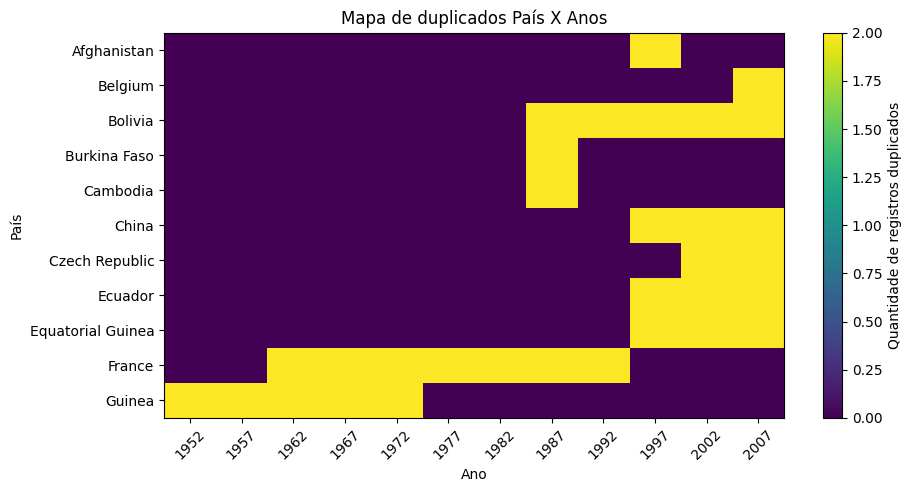

In [11]:
plt.figure(figsize=(10,5))
plt.imshow(matriz_dups, aspect='auto')
plt.title("Mapa de duplicados País X Anos")

plt.xlabel('Ano')
plt.ylabel('País')

plt.xticks(
    ticks=range(len(matriz_dups.columns)),
    labels=matriz_dups.columns,
    rotation=45,
)
plt.yticks(
    ticks=range(len(matriz_dups.index)),
    labels=matriz_dups.index,
)
plt.colorbar(label='Quantidade de registros duplicados')
plt.show()

In [12]:
df = df.drop_duplicates()

In [13]:
df.groupby(['country', 'year']).nunique().max()

pop          1
continent    1
lifeExp      1
gdpPercap    1
dtype: int64

### 5.2 Dados Ausentes


In [14]:
df.isna().sum()

country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64

### Validação da Cobertura Temporal Após a Limpeza


#### Estrutura Temporal e Cobertura do Dataset Principal


### Cobertura dos Anos

In [15]:
anos = df["year"].unique()
print("Quantidade de Anos: ",anos.shape[0])
anos

Quantidade de Anos:  12


array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

### Quantidade de Países

In [16]:
df["country"].unique().shape

(142,)

### Periodicidade

In [17]:
pd.Series(sorted(anos)).diff().value_counts()

5.0    11
Name: count, dtype: int64

### Países por Ano

In [18]:
paises_por_ano = df.groupby('year')['country'].nunique().reset_index(name='qtd_paises')
paises_por_ano.head()

,year,qtd_paises
0,1952,142
1,1957,142
2,1962,142
3,1967,142
4,1972,142


In [19]:
paises_por_ano.describe()

,year,qtd_paises
count,12.000000,12.0
mean,1979.500000,142.0
std,18.027756,0.0
min,1952.000000,142.0
25%,1965.750000,142.0
50%,1979.500000,142.0
75%,1993.250000,142.0
max,2007.000000,142.0


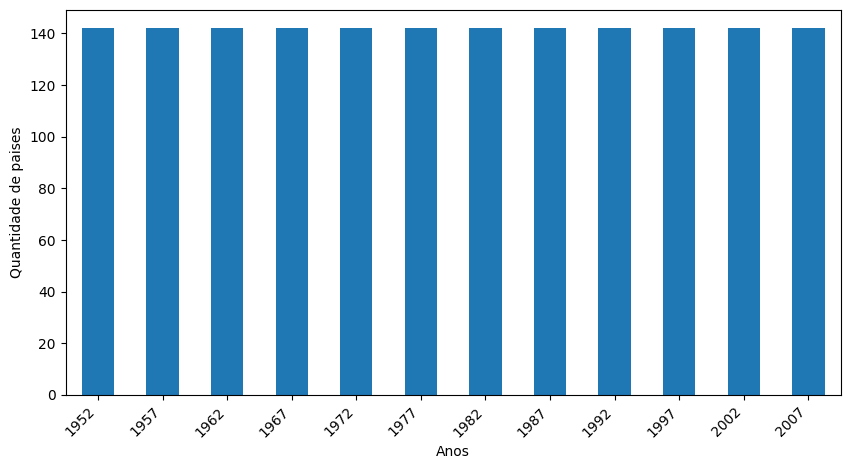

In [20]:
grafico_barra(
    (Coluna(nome_coluna="year",label="Anos",sortable=True),Coluna(nome_coluna="qtd_paises",label="Quantidade de paises",sortable=False)),
    data_frame=paises_por_ano

)

**_Estrutura Temporal do Dataset_**

Antes das análises exploratórias, foi realizada uma investigação da estrutura temporal do dataset para compreender a periodicidade das observações e verificar a consistência da cobertura entre os países.

A análise dos anos disponíveis mostrou que os dados são coletados em intervalos regulares de 5 anos, caracterizando uma periodicidade quinquenal.

Também foi avaliado se todos os países possuíam a mesma quantidade de observações ao longo do tempo. Essa verificação é importante para identificar possíveis séries temporais incompletas e garantir comparações consistentes entre países e continentes.

Os resultados indicam que o dataset possui estrutura temporal balanceada, com os países apresentando observações para os mesmos períodos históricos.

### 5.3 Dataset Enriquecido e Cobertura dos Indicadores

As análises centrais utilizam o dataset Gapminder original, com foco em expectativa de vida, PIB per capita, população, país, ano e continente. Para análises complementares, são incorporadas variáveis econômicas e sociais adicionais provenientes do dataset enriquecido.

Como `health_expenditure`, `drinking_water` e `literacy_rate` possuem cobertura temporal ou geográfica limitada, essas variáveis são utilizadas apenas como evidência complementar, não como eixo principal da análise histórica.

### Fontes dos Dados Complementares

Os indicadores complementares foram obtidos no portal **World Development Indicators**, do **Banco Mundial**, e integrados ao dataset Gapminder pelas colunas `country` e `year`, considerando os anos compatíveis com a série principal.

| Variável utilizada | Indicador original | Código do indicador | Fonte |
|---|---|---|---|
| `gdp_usd_correntes` | GDP (current US$) | `NY.GDP.MKTP.CD` | Banco Mundial |
| `health_expenditure` | Current health expenditure (% of GDP) | `SH.XPD.CHEX.GD.ZS` | Banco Mundial |
| `drinking_water` | People using at least basic drinking water services (% of population) | `SH.H2O.BASW.ZS` | Banco Mundial |
| `literacy_rate` | Literacy rate, adult total (% of people ages 15 and above) | `SE.ADT.LITR.ZS` | Banco Mundial |
| `infant_mortality_rate` | Mortality rate, infant (per 1,000 live births) | `SP.DYN.IMRT.IN` | Banco Mundial |

`gdp_usd_correntes` representa PIB total em USD correntes. Ele não é uma medida de crescimento real ajustado por inflação.

**Referências oficiais:**

- Banco Mundial. *GDP (current US$)* (`NY.GDP.MKTP.CD`). Disponível em: <https://data.worldbank.org/indicator/NY.GDP.MKTP.CD>.
- Banco Mundial. *Current health expenditure (% of GDP)* (`SH.XPD.CHEX.GD.ZS`). Disponível em: <https://data.worldbank.org/indicator/SH.XPD.CHEX.GD.ZS>.
- Banco Mundial. *People using at least basic drinking water services (% of population)* (`SH.H2O.BASW.ZS`). Disponível em: <https://data.worldbank.org/indicator/SH.H2O.BASW.ZS>.
- Banco Mundial. *Literacy rate, adult total (% of people ages 15 and above)* (`SE.ADT.LITR.ZS`). Disponível em: <https://data.worldbank.org/indicator/SE.ADT.LITR.ZS>.
- Banco Mundial. *Mortality rate, infant (per 1,000 live births)* (`SP.DYN.IMRT.IN`). Disponível em: <https://data.worldbank.org/indicator/SP.DYN.IMRT.IN>.

Os arquivos de origem utilizados para compor o dataset enriquecido são `gdp.csv`, `health_expenditure.csv`, `drinking_water.csv`, `literacy_rate.csv` e `mortality_rate.csv`, consolidados no arquivo `gap_minder_merged.csv`.


In [21]:
df_econ = pd.read_csv(Path("../datasets/gap_minder_merged.csv"))

# Remover duplicados exatos para manter a chave country-year única
df_econ = df_econ.drop_duplicates().copy()

# Normalização de aliases legados; o dataset atual já usa infant_mortality_rate.
df_econ = normalizar_colunas_enriquecidas(df_econ)

# Corrigir unidade do PIB total quando a coluna existir
if "gdp_usd_correntes" in df_econ.columns:
    df_econ["gdp_usd_bilhoes"] = (df_econ["gdp_usd_correntes"] / 1_000_000_000).round(2)
    df_econ["gdp_usd_trilhoes"] = (df_econ["gdp_usd_correntes"] / 1_000_000_000_000).round(2)

# Remover coluna antiga com nome/unidade ambígua, se existir
df_econ = df_econ.drop(columns=["gpd_trilhoes"], errors="ignore")

print("Shape do dataset enriquecido após limpeza:", df_econ.shape)
print("Duplicados por country-year:", df_econ.duplicated(subset=["country", "year"]).sum())
df_econ.head()

Shape do dataset enriquecido após limpeza: (1704, 14)
Duplicados por country-year: 0


,country,year,pop,continent,lifeExp,gdpPercap,health_expenditure,gdp_usd_correntes,drinking_water,literacy_rate,infant_mortality_rate,gdp_bilhoes_usd_correntes,gdp_usd_bilhoes,gdp_usd_trilhoes
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710,NaN,NaN,NaN,NaN,246.4,NaN,NaN,NaN
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138,NaN,NaN,NaN,NaN,232.4,NaN,NaN,NaN
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106,NaN,NaN,NaN,NaN,245.2,NaN,NaN,NaN


#### Cobertura dos Indicadores Enriquecidos

Antes de utilizar os indicadores externos, é necessário avaliar sua cobertura. Indicadores com baixa cobertura podem gerar correlações aparentemente fortes, mas baseadas em subconjuntos pequenos ou concentrados em poucos anos.


In [22]:
indicadores_enriquecidos = [
    col for col in [
        "health_expenditure",
        "drinking_water",
        "literacy_rate",
        "infant_mortality_rate",
        "gdp_usd_correntes"
    ] if col in df_econ.columns
]

cobertura = (
    df_econ[indicadores_enriquecidos]
    .notna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

cobertura.columns = ["indicador", "cobertura_percentual"]
cobertura

,indicador,cobertura_percentual
0,infant_mortality_rate,67.253521
1,gdp_usd_correntes,64.319249
2,health_expenditure,14.143192
3,drinking_water,13.967136
4,literacy_rate,3.169014


In [23]:
# Cobertura por ano dos indicadores enriquecidos
cobertura_por_ano = (
    df_econ
    .groupby("year")[indicadores_enriquecidos]
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
)

cobertura_por_ano

,health_expenditure,drinking_water,literacy_rate,infant_mortality_rate,gdp_usd_correntes
year,,,,,
1952,0.00,0.00,0.00,0.00,0.00
1957,0.00,0.00,0.00,0.00,0.00
1962,0.00,0.00,0.00,65.49,64.08
1967,0.00,0.00,0.00,70.42,66.90
1972,0.00,0.00,0.00,75.35,71.13
1977,0.00,0.00,0.00,78.87,71.83
1982,0.00,0.00,4.93,83.80,76.76
1987,0.00,0.00,1.41,86.62,78.17
1992,0.00,0.00,5.63,86.62,83.80


A cobertura dos indicadores enriquecidos confirma que nem todas as variáveis podem ser utilizadas para análises históricas completas. `health_expenditure`, `drinking_water` e `literacy_rate` são indicadores complementares cuja cobertura limita a força das interpretações. Em particular, `health_expenditure` e `drinking_water` possuem cobertura concentrada em anos recentes, especialmente 2002 e 2007; suas análises são recortes pontuais.

A variável `infant_mortality_rate`, por apresentar cobertura maior, é a mais útil entre os indicadores enriquecidos para complementar a análise de expectativa de vida, ainda sem permitir inferência causal.


## 6. Evolução Global da Expectativa de Vida


### 6.1 Média Simples Global


In [24]:
life_global = df.groupby('year')['lifeExp'].mean().reset_index()
life_global.head()

,year,lifeExp
0,1952,49.057620
1,1957,51.507401
2,1962,53.609249
3,1967,55.678290
4,1972,57.647386


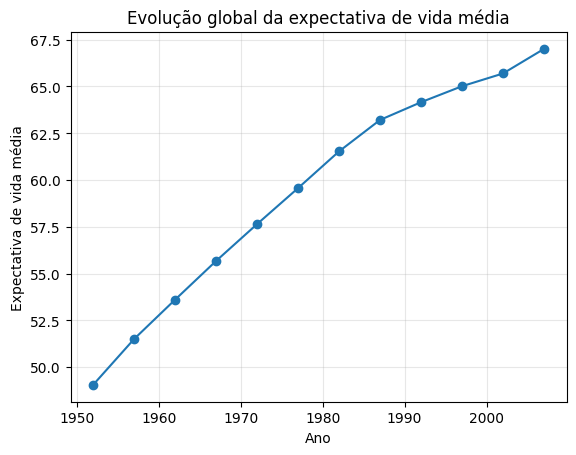

In [25]:
grafico_linha(
    data_frame=life_global,
    coluna_x="year",
    coluna_y="lifeExp",
    titulo="Evolução global da expectativa de vida média",
    xlabel="Ano",
    ylabel="Expectativa de vida média",
)


### 6.2 Média Simples vs Média Ponderada pela População

A média global simples trata todos os países com o mesmo peso. No entanto, países com populações muito diferentes representam quantidades muito distintas de pessoas.

Por isso, foi calculada também uma média ponderada pela população, permitindo comparar duas perspectivas:

- **média simples:** cada país possui o mesmo peso;
- **média ponderada:** países mais populosos influenciam mais o resultado global.


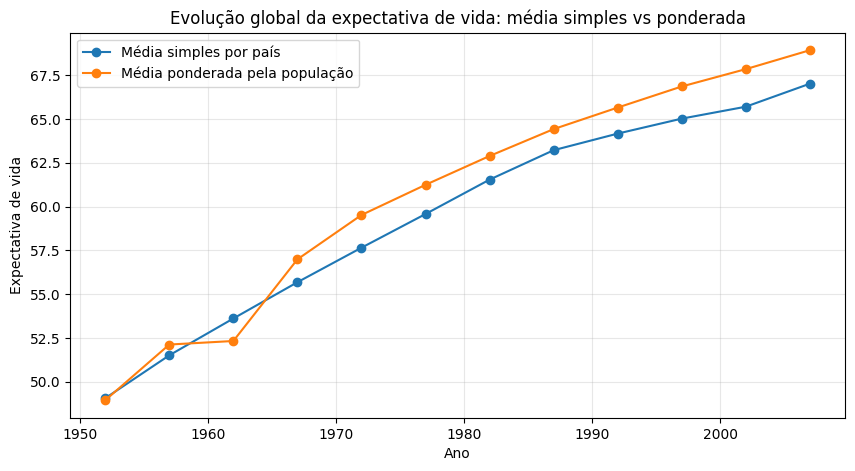

,year,lifeExp_media_simples,lifeExp_ponderada_populacao
0,1952,49.057620,48.944237
1,1957,51.507401,52.121885
2,1962,53.609249,52.324382
3,1967,55.678290,56.984307
4,1972,57.647386,59.514783
5,1977,59.570157,61.237256
6,1982,61.533197,62.881755
7,1987,63.212613,64.416350
8,1992,64.160338,65.645900
9,1997,65.014676,66.849343


In [26]:
life_global_mean = (
    df.groupby("year")["lifeExp"]
    .mean()
    .reset_index(name="lifeExp_media_simples")
)

life_global_weighted = calcular_media_ponderada_por_ano(
    data_frame=df,
    coluna_valor="lifeExp",
    coluna_peso="pop",
    nome_resultado="lifeExp_ponderada_populacao",
)

life_global_compare = life_global_mean.merge(
    life_global_weighted,
    on="year",
)

plt.figure(figsize=(10, 5))

plt.plot(
    life_global_compare["year"],
    life_global_compare["lifeExp_media_simples"],
    marker="o",
    label="Média simples por país",
)

plt.plot(
    life_global_compare["year"],
    life_global_compare["lifeExp_ponderada_populacao"],
    marker="o",
    label="Média ponderada pela população",
)

aplicar_formatacao_grafico(
    titulo="Evolução global da expectativa de vida: média simples vs ponderada",
    xlabel="Ano",
    ylabel="Expectativa de vida",
    legend=True,
)

life_global_compare


A comparação entre média simples e média ponderada pela população revela uma diferença metodológica importante. A média simples considera cada país com o mesmo peso, enquanto a média ponderada atribui maior influência aos países mais populosos.

Observa-se que, nos primeiros anos da série, especialmente em 1952 e meados da década de 1960, a média ponderada era inferior à média simples. Isso sugere que países com grande população apresentavam expectativa de vida relativamente menor nesse período, puxando a média populacional para baixo.

Ao longo do tempo, a aproximação e posterior elevação da média ponderada indicam melhora significativa em países populosos, contribuindo de forma expressiva para o aumento da expectativa de vida global.

In [27]:
df_ano_62 = filtrar_ano(df, 1962)
media_simples = df_ano_62["lifeExp"].mean()
top_ano = top_n(
    df_ano_62,
    coluna="pop",
    n=10,
    colunas=["country", "continent", "pop", "lifeExp", "gdpPercap"],
)
top_ano["media_simples_ano"] = media_simples
top_ano["dif_lifeExp_media"] = top_ano["lifeExp"] - top_ano["media_simples_ano"]
top_ano

,country,continent,pop,lifeExp,gdpPercap,media_simples_ano,dif_lifeExp_media
299,China,Asia,665770000.0,44.50136,487.674018,53.609249,-9.107889
730,India,Asia,454000000.0,43.60500,658.347151,53.609249,-10.004249
1642,United States,Americas,186538000.0,70.21000,16173.145860,53.609249,16.600751
742,Indonesia,Asia,99028000.0,42.51800,849.289770,53.609249,-11.091249
826,Japan,Asia,95831757.0,68.73000,6576.649461,53.609249,15.120751
177,Brazil,Americas,76039390.0,55.66500,3336.585802,53.609249,2.055751
593,Germany,Europe,73739117.0,70.30000,12902.462910,53.609249,16.690751
99,Bangladesh,Asia,56839289.0,41.21600,686.341554,53.609249,-12.393249
1630,United Kingdom,Europe,53292000.0,70.76000,12477.177070,53.609249,17.150751
1198,Pakistan,Asia,53100671.0,47.67000,803.342742,53.609249,-5.939249


Em 1962, a média simples sugeria uma condição global melhor do que a média ponderada pela população. Isso indica que o progresso em expectativa de vida ainda não estava distribuído proporcionalmente entre as populações mais numerosas do mundo.

## 7. Evolução por Continente

### 7.1 Evolução Média por Continente


In [28]:
expect_vida_continente = df.groupby(["continent","year"])["lifeExp"].mean().reset_index()
expect_vida_continente.sort_values(by="lifeExp", ascending=False).head(10)

,continent,year,lifeExp
59,Oceania,2007,80.719500
58,Oceania,2002,79.740000
57,Oceania,1997,78.190000
47,Europe,2007,77.648600
56,Oceania,1992,76.945000
46,Europe,2002,76.700600
45,Europe,1997,75.505167
55,Oceania,1987,75.320000
44,Europe,1992,74.440100
54,Oceania,1982,74.290000


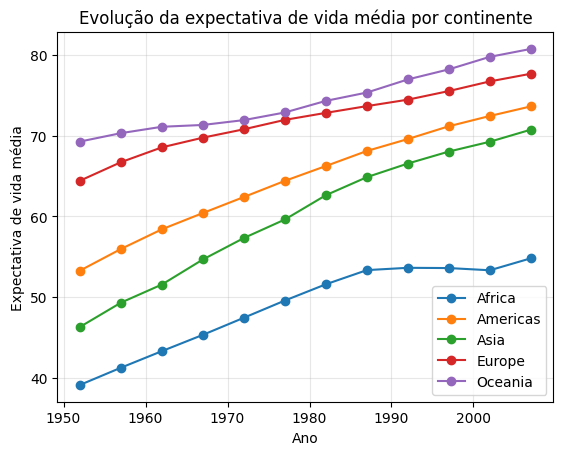

In [29]:
grafico_linhas_por_grupo(
    data_frame=expect_vida_continente,
    grupo="continent",
    coluna_x="year",
    coluna_y="lifeExp",
    titulo="Evolução da expectativa de vida média por continente",
    xlabel="Ano",
    ylabel="Expectativa de vida média",
)


### 7.2 Crescimento Absoluto por Continente

Além de observar as curvas de evolução, foi calculado o crescimento absoluto da expectativa de vida média por continente entre 1952 e 2007. Essa análise ajuda a diferenciar duas dimensões: o nível final alcançado e o avanço acumulado ao longo do período.

Um continente pode apresentar grande crescimento e, ainda assim, permanecer abaixo de outros que já estavam em patamares elevados no início da série.

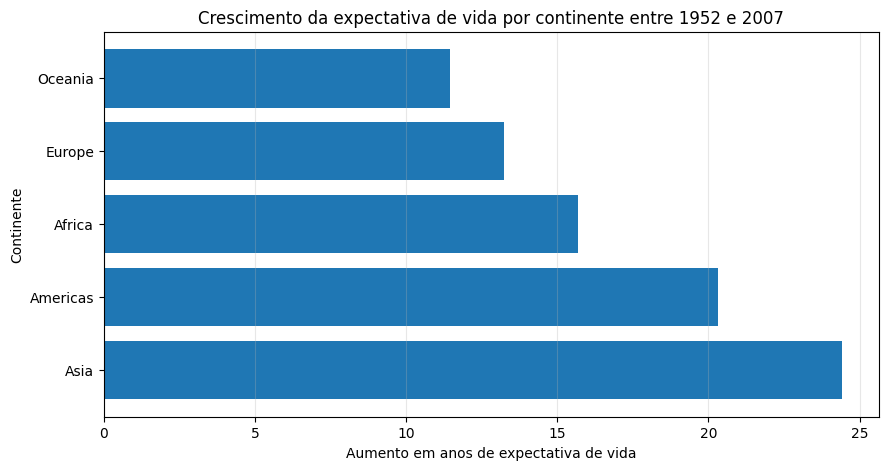

,continent,crescimento_1952_2007
0,Oceania,11.464500
1,Europe,13.240100
2,Africa,15.670538
3,Americas,20.328280
4,Asia,24.414091


In [30]:
life_continent_pivot = calcular_variacao_periodo(
    data_frame=expect_vida_continente,
    indice="continent",
    valor="lifeExp",
    ano_inicial=1952,
    ano_final=2007,
)

crescimento_continente = (
    life_continent_pivot["crescimento_1952_2007"]
    .sort_values(ascending=True)
    .reset_index()
)

plotar_barras_horizontais(
    data_frame=crescimento_continente,
    coluna_categoria="continent",
    coluna_valor="crescimento_1952_2007",
    titulo="Crescimento da expectativa de vida por continente entre 1952 e 2007",
    xlabel="Aumento em anos de expectativa de vida",
    ylabel="Continente",
)

crescimento_continente

O gráfico mostra quais continentes tiveram maior avanço absoluto no período. Essa leitura complementa o gráfico de linhas: enquanto a curva temporal mostra a trajetória ano a ano, o crescimento absoluto resume a variação acumulada entre o início e o fim da série.

Essa comparação evita uma interpretação baseada apenas no ranking final. Continentes que partiram de níveis mais baixos podem apresentar crescimento expressivo, mesmo permanecendo abaixo de continentes que já tinham expectativa de vida elevada em 1952.

## 8. Desigualdade entre Continentes

### 8.1 Dispersão por Continente ao Longo da Série

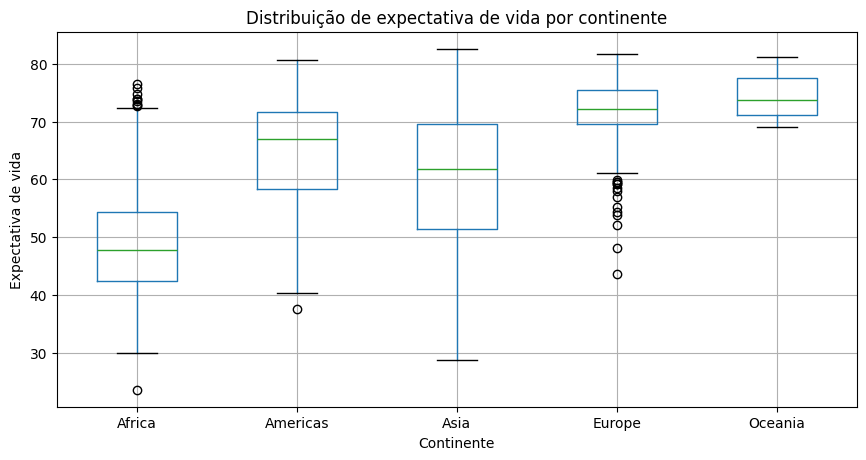

In [31]:
plotar_boxplot_por_grupo(
    data_frame=df,
    coluna_valor="lifeExp",
    coluna_grupo="continent",
    titulo="Distribuição de expectativa de vida por continente",
    xlabel="Continente",
    ylabel="Expectativa de vida",
)


O boxplot por continente evidencia diferenças importantes na distribuição da expectativa de vida entre regiões. Enquanto Europa e Oceania concentram valores mais altos, África apresenta valores mais baixos e maior distância em relação aos continentes líderes.

Essa visualização complementa a análise de evolução temporal porque mostra a dispersão dos dados, não apenas as médias. Assim, ela ajuda a identificar desigualdades estruturais entre continentes ao longo da série histórica.

O boxplot evidencia padrões distintos entre continentes. Na África, os outliers aparecem principalmente acima da distribuição central, indicando países ou anos com expectativa de vida significativamente superior ao padrão continental. Na Europa, ocorre o inverso: os outliers aparecem abaixo da distribuição central, indicando observações que ficaram abaixo do padrão europeu.

Esse comportamento sugere que os continentes possuem assimetrias internas diferentes. Na África, os casos extremos positivos se destacam em relação a uma base continental mais baixa. Na Europa, os casos extremos negativos se destacam em relação a uma base continental mais elevada e mais concentrada.

Ainda assim, as magnitudes não são equivalentes: os outliers inferiores da Europa permanecem em faixas de expectativa de vida relativamente altas quando comparados aos menores valores observados na África.

### 8.2 Diferença Europa vs África

Após observar que Europa e África ocupam posições bastante distintas nos gráficos anteriores, foi calculada a diferença entre suas expectativas de vida médias ao longo do tempo. Essa análise permite acompanhar se a distância entre esses dois extremos continentais diminuiu ou permaneceu relevante.

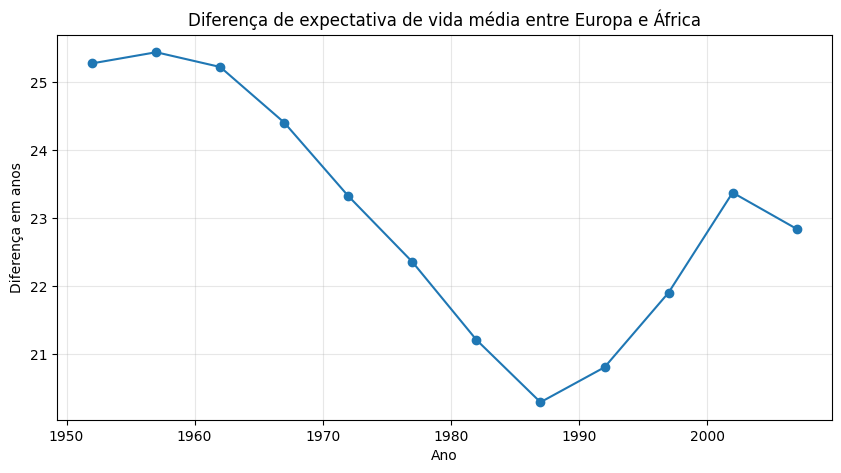

continent,Europe,Africa,gap_europe_africa
year,,,
1952,64.408500,39.135500,25.273000
1957,66.703067,41.266346,25.436721
1962,68.539233,43.319442,25.219791
1967,69.737600,45.334538,24.403062
1972,70.775033,47.450942,23.324091
1977,71.937767,49.580423,22.357344
1982,72.806400,51.592865,21.213535
1987,73.642167,53.344788,20.297378
1992,74.440100,53.629577,20.810523


In [32]:
life_gap_europa_africa = (
    expect_vida_continente[
        expect_vida_continente["continent"].isin(["Europe", "Africa"])
    ]
    .pivot(index="year", columns="continent", values="lifeExp")
)

life_gap_europa_africa["gap_europe_africa"] = (
    life_gap_europa_africa["Europe"] - life_gap_europa_africa["Africa"]
)

plt.figure(figsize=(10, 5))
plt.plot(
    life_gap_europa_africa.index,
    life_gap_europa_africa["gap_europe_africa"],
    marker="o",
)

plt.title("Diferença de expectativa de vida média entre Europa e África")
plt.xlabel("Ano")
plt.ylabel("Diferença em anos")
plt.grid(True, alpha=0.3)
plt.show()

life_gap_europa_africa[["Europe", "Africa", "gap_europe_africa"]]

A diferença entre Europa e África mostra que a melhora global da expectativa de vida não eliminou as desigualdades regionais. Mesmo com avanços ao longo do tempo, a distância entre esses continentes permaneceu relevante dentro do período analisado.

Essa análise não explica as causas da diferença, mas evidencia a persistência de desigualdade continental no indicador de longevidade.

### 8.3 Oceania vs Europa em 2007

A Oceania aparece frequentemente com média elevada de expectativa de vida. No entanto, ela possui poucos países no dataset, o que torna sua média mais concentrada e sensível ao tamanho da amostra.

Por isso, a comparação com a Europa deve considerar não apenas a média, mas também a quantidade de países, a mediana, o desvio padrão e a dispersão em 2007.

In [33]:
df_2007 = filtrar_ano(df, 2007)

comparacao_continentes_2007 = (
    df_2007
    .groupby("continent")["lifeExp"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

comparacao_continentes_2007


,count,mean,median,std,min,max
continent,,,,,,
Oceania,2,80.719500,80.7195,0.729027,80.204,81.235
Europe,30,77.648600,78.6085,2.979813,71.777,81.757
Americas,25,73.608120,72.8990,4.440948,60.916,80.653
Asia,33,70.728485,72.3960,7.963724,43.828,82.603
Africa,52,54.806038,52.9265,9.630781,39.613,76.442


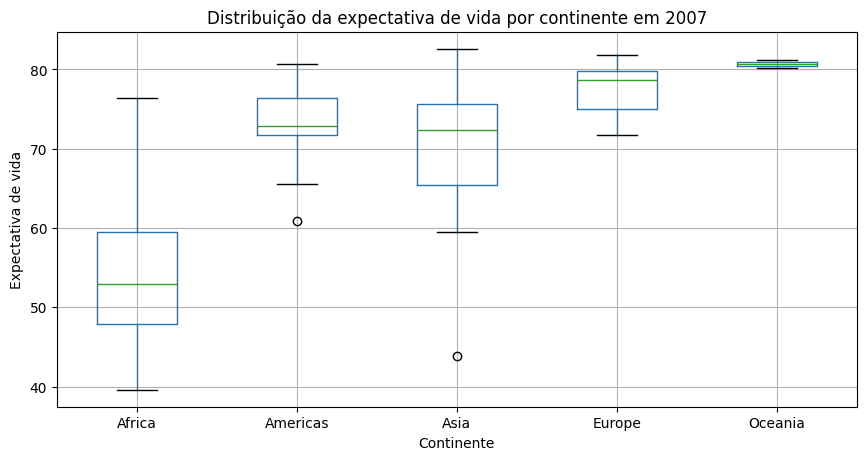

In [34]:
plotar_boxplot_por_grupo(
    data_frame=df_2007,
    coluna_valor="lifeExp",
    coluna_grupo="continent",
    titulo="Distribuição da expectativa de vida por continente em 2007",
    xlabel="Continente",
    ylabel="Expectativa de vida",
)


A tabela e o boxplot mostram que a Oceania apresenta expectativa de vida elevada em 2007, mas sua interpretação exige cautela porque há poucos países representados. A Europa, por outro lado, possui mais países e maior heterogeneidade interna.

Assim, a média da Oceania não deve ser lida automaticamente como evidência de superioridade continental ampla; ela representa um grupo menor e mais concentrado dentro do dataset.

## 9. Desigualdade entre Países


### 9.1 Top 10 Expectativa de Vida


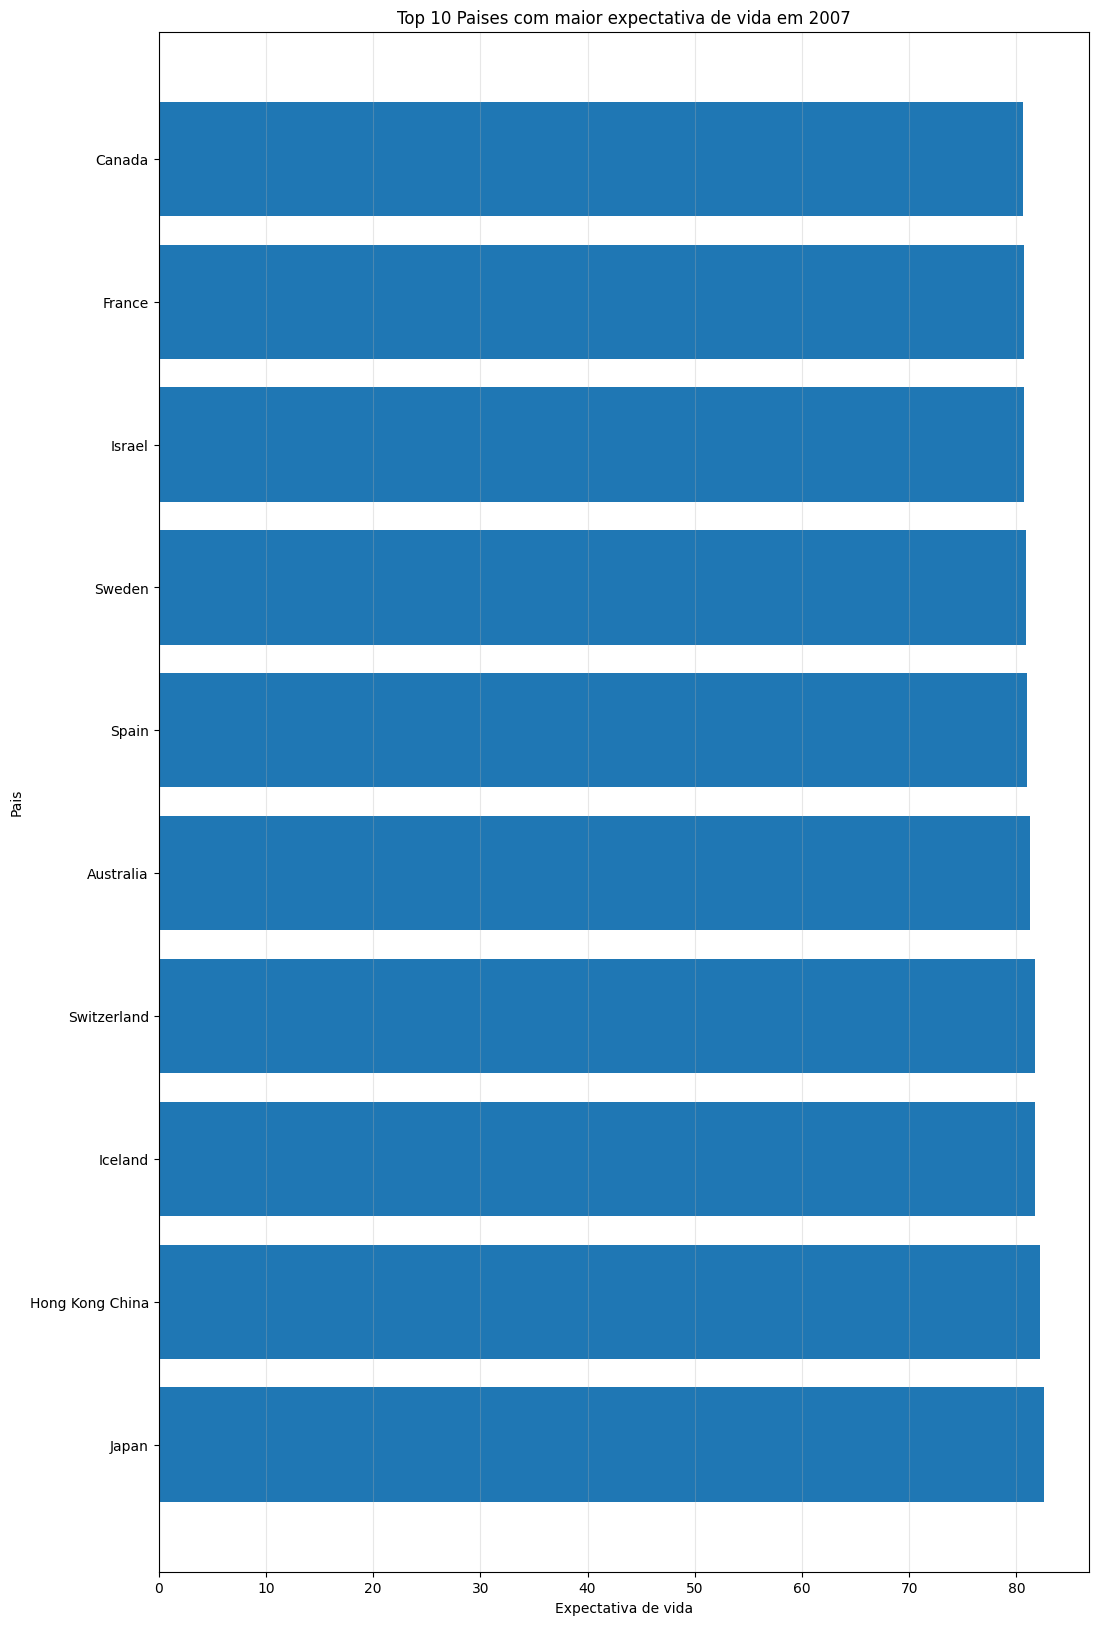

In [35]:
colunas = (Coluna(nome_coluna="country", label="Pais", sortable=False),
           Coluna(nome_coluna="lifeExp", label="Expectativa de vida", sortable=True))

ano_mais_recente = df['year'].max()
plotar_ranking_por_ano(
    ano=ano_mais_recente,
    data_frame=df,
    colunas=colunas,
    titulo=f"Top 10 Paises com maior expectativa de vida em {ano_mais_recente}",
    quantidade=10,
)

### Mapa mundial da expectativa de vida em 2007

Além dos rankings, um mapa permite observar a distribuição espacial da expectativa de vida no ano mais recente do dataset. Esta visualização é complementar: ela ajuda a identificar padrões geográficos amplos, mas não substitui as análises quantitativas por continente e por país.

In [36]:
try:
    import plotly.express as px

    fig = px.choropleth(
        df_2007,
        locations="country",
        locationmode="country names",
        color="lifeExp",
        hover_name="country",
        hover_data={"continent": True, "lifeExp": ":.1f", "gdpPercap": ":.0f", "pop": ":,.0f"},
        color_continuous_scale="Viridis",
        title=f"Expectativa de vida por país em {df_2007['year'].iloc[0]}"
    )
    fig.show()
except Exception as exc:
    print("Mapa interativo não foi gerado neste ambiente.")
    print("Motivo:", exc)
    print("A análise permanece válida com os gráficos de ranking, boxplot e dispersão já apresentados.")

/tmp/ipykernel_159005/2274192651.py:4: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


O mapa reforça visualmente a existência de blocos regionais com diferentes níveis de expectativa de vida. Países da Europa, Oceania e parte da Ásia aparecem entre os maiores valores, enquanto parte relevante da África permanece em faixas inferiores.

### 9.2 Persistência no Top 10


In [37]:
top10_por_ano = df.sort_values(['year', 'lifeExp'], ascending=[True, False]).groupby('year').head(10)

frequencia_top10 = top10_por_ano["country"].value_counts().reset_index()
frequencia_top10.columns = ["country","frequencia_top10"]
frequencia_top10.head(10)

,country,frequencia_top10
0,Iceland,12
1,Sweden,12
2,Switzerland,12
3,Canada,12
4,Spain,9
5,Netherlands,8
6,Japan,8
7,Norway,7
8,Australia,7
9,France,7


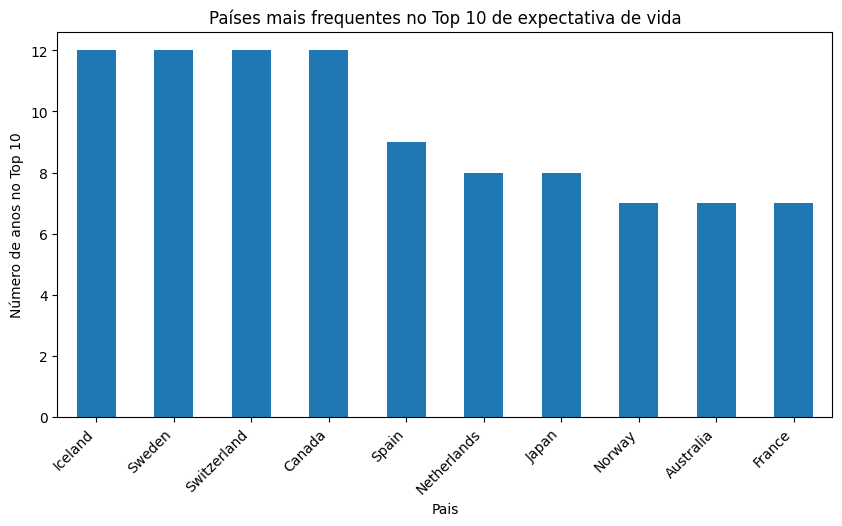

In [38]:
grafico_barra(
    (Coluna(nome_coluna="country",label="Pais",sortable=False),Coluna(nome_coluna="frequencia_top10",label="Número de anos no Top 10",sortable=True)),
    quantidade=10,
    data_frame=frequencia_top10,
     title="Países mais frequentes no Top 10 de expectativa de vida", scale=None
)

O gráfico de persistência no Top 10 mostra que alguns países aparecem repetidamente entre os maiores valores de expectativa de vida ao longo da série histórica. Isso identifica continuidade de posições elevadas no indicador, sem determinar quais mecanismos a produziram.

Condições como renda, saneamento, educação, cobertura de saúde e estabilidade institucional são hipóteses para investigação complementar, e não conclusões diretas desta análise.

Portanto, a persistência no Top 10 evidencia que o avanço global da expectativa de vida não eliminou completamente as desigualdades históricas observadas entre países.


### 9.3 Países com Maior Crescimento

Além de observar os países líderes em expectativa de vida, é importante identificar quais países apresentaram maior evolução entre o primeiro e o último ano do dataset. O gráfico evidencia a melhoria no indicador de longevidade.


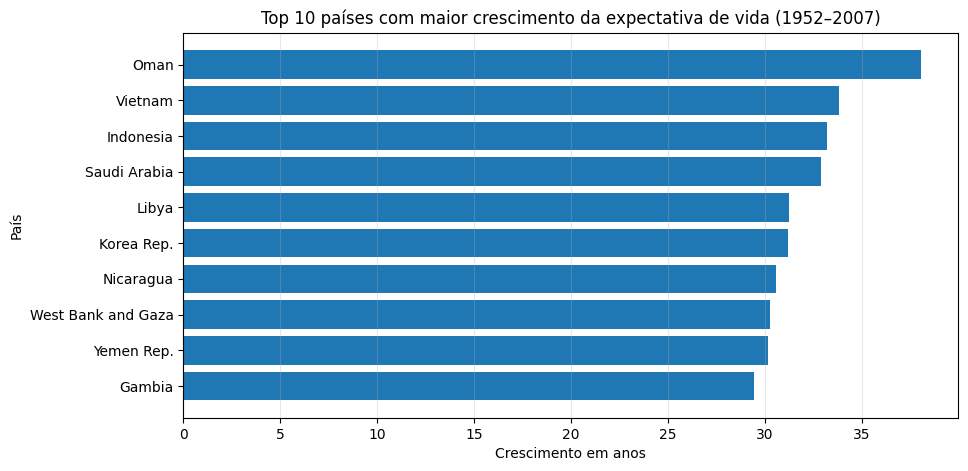

year,country,crescimento_1952_2007
0,Oman,38.062
1,Vietnam,33.837
2,Indonesia,33.182
3,Saudi Arabia,32.902
4,Libya,31.229
5,Korea Rep.,31.170
6,Nicaragua,30.585
7,West Bank and Gaza,30.262
8,Yemen Rep.,30.150
9,Gambia,29.448


In [39]:
life_growth = calcular_variacao_periodo(
    data_frame=df,
    indice="country",
    valor="lifeExp",
    ano_inicial=1952,
    ano_final=2007,
)

maiores_crescimentos = (
    top_n(
        life_growth[["crescimento_1952_2007"]],
        coluna="crescimento_1952_2007",
        n=10,
    )
    .reset_index()
)

plotar_barras_horizontais(
    data_frame=maiores_crescimentos,
    coluna_categoria="country",
    coluna_valor="crescimento_1952_2007",
    titulo="Top 10 países com maior crescimento da expectativa de vida (1952–2007)",
    xlabel="Crescimento em anos",
    ylabel="País",
)

maiores_crescimentos


A análise dos países com maior crescimento absoluto da expectativa de vida entre 1952 e 2007 mostra que os maiores avanços ocorreram principalmente em países da Ásia, além de alguns países da África e das Américas.

Os maiores ganhos históricos não ocorreram necessariamente nos países que já possuíam os maiores níveis de expectativa de vida, mas em países que partiram de patamares mais baixos e registraram forte aumento ao longo do período analisado.

Essa distinção é importante porque o ranking final de expectativa de vida mostra os países em melhor posição em 2007, enquanto o crescimento absoluto revela trajetórias distintas. Países da Europa e da Oceania já apresentavam valores elevados em 1952, reduzindo o espaço para grandes aumentos absolutos; países asiáticos, africanos e latino-americanos tinham maior margem para variação.

Possíveis relações com saúde pública, saneamento, educação, urbanização ou infraestrutura são hipóteses para investigação complementar. O dataset analisado não estabelece causalidade para esses fatores.


In [40]:
life_growth_detalhado = calcular_variacao_periodo(
    data_frame=df[df["country"].isin(maiores_crescimentos["country"])],
    indice=["country", "continent"],
    valor="lifeExp",
    ano_inicial=1952,
    ano_final=2007,
).reset_index()

life_growth_detalhado =  life_growth_detalhado.sort_values("crescimento_1952_2007", ascending=False)

life_growth_detalhado[["country",'continent',1952,2007,"crescimento_1952_2007"]]

year,country,continent,1952,2007,crescimento_1952_2007
5,Oman,Asia,37.578,75.640,38.062
7,Vietnam,Asia,40.412,74.249,33.837
1,Indonesia,Asia,37.468,70.650,33.182
6,Saudi Arabia,Asia,39.875,72.777,32.902
3,Libya,Africa,42.723,73.952,31.229
2,Korea Rep.,Asia,47.453,78.623,31.170
4,Nicaragua,Americas,42.314,72.899,30.585
8,West Bank and Gaza,Asia,43.160,73.422,30.262
9,Yemen Rep.,Asia,32.548,62.698,30.150
0,Gambia,Africa,30.000,59.448,29.448


### 9.4 Disparidade Global: Amplitude Total vs Amplitude Robusta


In [41]:
disparidade_ano = df.groupby('year')['lifeExp'].agg(["min", "mean", "median", "max"]).reset_index()
disparidade_ano["amplitude"] = disparidade_ano["max"] - disparidade_ano["min"]
disparidade_ano


,year,min,mean,median,max,amplitude
0,1952,28.801,49.057620,45.1355,72.670,43.869
1,1957,30.332,51.507401,48.3605,73.470,43.138
2,1962,31.997,53.609249,50.8810,73.680,41.683
3,1967,34.020,55.678290,53.8250,74.160,40.140
4,1972,35.400,57.647386,56.5300,74.720,39.320
5,1977,31.220,59.570157,59.6720,76.110,44.890
6,1982,38.445,61.533197,62.4415,77.110,38.665
7,1987,39.906,63.212613,65.8340,78.670,38.764
8,1992,23.599,64.160338,67.7030,79.360,55.761
9,1997,36.087,65.014676,69.3940,80.690,44.603


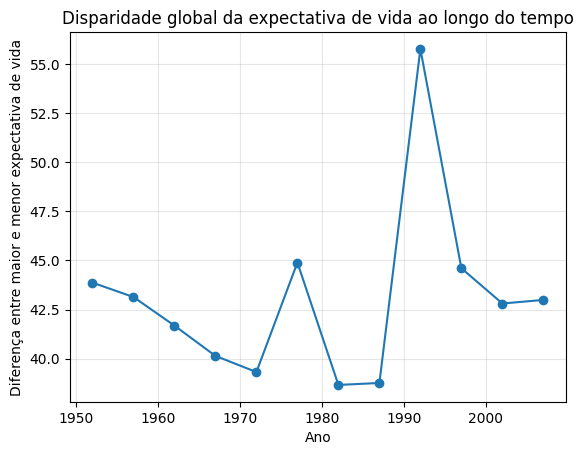

In [42]:
grafico_linha(
    data_frame=disparidade_ano,
    coluna_x="year",
    coluna_y="amplitude",
    titulo="Disparidade global da expectativa de vida ao longo do tempo",
    xlabel="Ano",
    ylabel="Diferença entre maior e menor expectativa de vida",
)


O gráfico de amplitude total mostra variações importantes na diferença entre o país com maior e menor expectativa de vida ao longo do tempo. O pico observado em 1992 sugere a necessidade de investigar quais países estão formando esses extremos.

Para aprofundar a análise, foram investigadas três perguntas:

- Em qual ano a disparidade foi maior?
- Qual país puxou o valor mínimo da expectativa de vida para baixo?
- Qual país apresentou o maior valor de expectativa de vida naquele mesmo ano?

In [43]:
idx_min = df.groupby("year")["lifeExp"].idxmin()
idx_max = df.groupby("year")["lifeExp"].idxmax()

minimos = df.loc[idx_min, ["year","country","continent","lifeExp"]].rename(
    columns={
        "country":"pais_menor_lifeExp",
        "continent":"continent_menor_lifeExp",
        "lifeExp":"menor_lifeExp",
    }
)

maximos = df.loc[idx_max, ["year","country","continent","lifeExp"]].rename(
    columns={
        "country":"pais_maior_lifeExp",
        "continent":"continent_maior_lifeExp",
        "lifeExp":"maior_lifeExp",
    }
)

disparidades_extremos = minimos.merge(maximos, on="year")

disparidades_extremos["amplitude_lifeExp"]      =(
    disparidades_extremos["maior_lifeExp"]      - disparidades_extremos["menor_lifeExp"]
)

disparidades_extremos.sort_values("amplitude_lifeExp", ascending=False)

,year,pais_menor_lifeExp,continent_menor_lifeExp,menor_lifeExp,pais_maior_lifeExp,continent_maior_lifeExp,maior_lifeExp,amplitude_lifeExp
8,1992,Rwanda,Africa,23.599,Japan,Asia,79.360,55.761
5,1977,Cambodia,Asia,31.220,Iceland,Europe,76.110,44.890
9,1997,Rwanda,Africa,36.087,Japan,Asia,80.690,44.603
0,1952,Afghanistan,Asia,28.801,Norway,Europe,72.670,43.869
1,1957,Afghanistan,Asia,30.332,Iceland,Europe,73.470,43.138
11,2007,Swaziland,Africa,39.613,Japan,Asia,82.603,42.990
10,2002,Zambia,Africa,39.193,Japan,Asia,82.000,42.807
2,1962,Afghanistan,Asia,31.997,Iceland,Europe,73.680,41.683
3,1967,Afghanistan,Asia,34.020,Sweden,Europe,74.160,40.140
4,1972,Sierra Leone,Africa,35.400,Sweden,Europe,74.720,39.320




A amplitude total é útil para identificar extremos, mas pode ser muito sensível a casos isolados. Um único país com expectativa de vida muito baixa pode aumentar fortemente a diferença entre máximo e mínimo durante os anos de 1992.


In [44]:
disparidade_robusta = df.groupby("year")["lifeExp"].agg(
    minimo="min",
    maximo="max",
    media="mean",
    mediana="median",
    desvio_padrao="std",
    p10=lambda x: np.percentile(x, 10),
    p90=lambda x: np.percentile(x, 90),
).reset_index()

disparidade_robusta["amplitude_total"]   = (
    disparidade_robusta["maximo"] - disparidade_robusta["minimo"]
)

disparidade_robusta["amplitude_p90_p10"] = (
    disparidade_robusta["p90"] - disparidade_robusta["p10"]
)

disparidade_robusta


,year,minimo,maximo,media,mediana,desvio_padrao,p10,p90,amplitude_total,amplitude_p90_p10
0,1952,28.801,72.670,49.057620,45.1355,12.225956,35.5095,66.9060,43.869,31.3965
1,1957,30.332,73.470,51.507401,48.3605,12.231286,37.3416,68.9270,43.138,31.5854
2,1962,31.997,73.680,53.609249,50.8810,12.097245,39.4012,70.2460,41.683,30.8448
3,1967,34.020,74.160,55.678290,53.8250,11.718858,41.0832,71.0780,40.140,29.9948
4,1972,35.400,74.720,57.647386,56.5300,11.381953,42.6347,71.9930,39.320,29.3583
5,1977,31.220,76.110,59.570157,59.6720,11.227229,44.2085,73.4340,44.890,29.2255
6,1982,38.445,77.110,61.533197,62.4415,10.770618,45.6604,74.6220,38.665,28.9616
7,1987,39.906,78.670,63.212613,65.8340,10.556285,46.9386,75.3170,38.764,28.3784
8,1992,23.599,79.360,64.160338,67.7030,11.227380,48.1207,76.4560,55.761,28.3353
9,1997,36.087,80.690,65.014676,69.3940,11.559439,47.4671,77.5480,44.603,30.0809


Por isso, além da amplitude total, foi calculada uma medida mais robusta de disparidade: a diferença entre o percentil 90 e o percentil 10 da expectativa de vida. Essa métrica reduz a influência dos casos extremos e permite observar melhor a desigualdade entre a maior parte dos países.

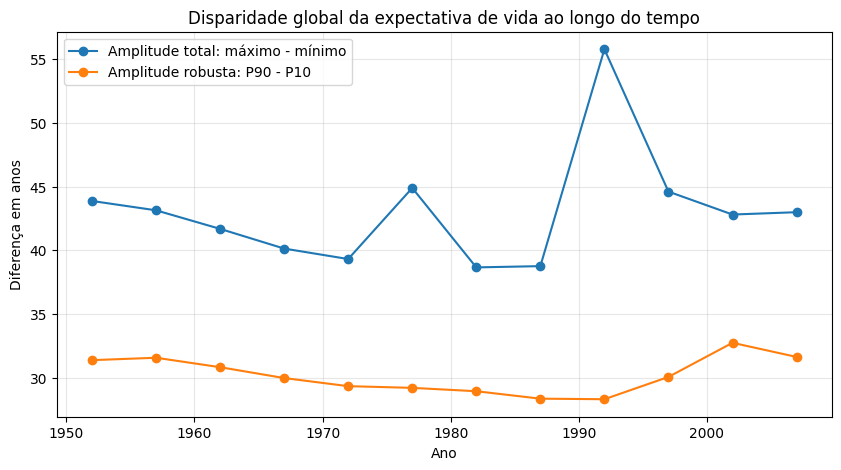

In [45]:
plt.figure(figsize=(10,5))

plt.plot(
    disparidade_robusta["year"],
    disparidade_robusta["amplitude_total"],
    marker="o",
    label="Amplitude total: máximo - mínimo",
)

plt.plot(
    disparidade_robusta["year"],
    disparidade_robusta["amplitude_p90_p10"],
    marker="o",
    label="Amplitude robusta: P90 - P10"
)

plt.title("Disparidade global da expectativa de vida ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Diferença em anos")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


A comparação entre a amplitude total e a amplitude robusta mostra que a desigualdade global da expectativa de vida deve ser interpretada com cautela. A amplitude total, calculada como a diferença entre o maior e o menor valor observado em cada ano, é muito sensível a casos extremos. Por isso, ela apresenta variações bruscas quando um país específico registra expectativa de vida muito baixa.

O caso mais evidente ocorre em 1992, quando Rwanda apresentou a menor expectativa de vida do dataset, com 23,599 anos, enquanto o Japão apresentou 79,360 anos. Isso gerou a maior amplitude total da série, com diferença superior a 55 anos. No entanto, a amplitude robusta, calculada pela diferença entre os percentis 90 e 10, não apresentou aumento equivalente nesse mesmo ano.

Essa diferença entre as métricas indica que o pico de desigualdade observado em 1992 foi fortemente influenciado por um caso extremo, e não necessariamente por uma piora generalizada em toda a distribuição dos países. A amplitude robusta sugere que, entre 1952 e o final dos anos 1980, houve redução gradual da desigualdade entre a maior parte dos países. A partir dos anos 1990 e 2000, observa-se novamente aumento da diferença robusta, indicando que as desigualdades entre grupos de países permaneceram relevantes.

Portanto, a análise mostra que médias globais e amplitudes simples podem ocultar ou exagerar fenômenos específicos. O uso combinado de amplitude total e amplitude robusta permite diferenciar choques extremos de desigualdades mais estruturais na expectativa de vida.

## 10. Heterogeneidade Regional

### 10.1 Heterogeneidade da Ásia


#### Distribuição interna da Ásia em 2007

In [46]:
df_asia_2007 = filtrar_ano(df, 2007)
df_asia_2007 = df_asia_2007[df_asia_2007["continent"] == "Asia"].copy()
top_n(
    df_asia_2007,
    coluna="lifeExp",
    n=10,
    colunas=["country", "lifeExp", "gdpPercap", "pop"],
)

,country,lifeExp,gdpPercap,pop
835,Japan,82.603,31656.068060,127467972.0
703,Hong Kong China,82.208,39724.978670,6980412.0
799,Israel,80.745,25523.277100,6426679.0
1399,Singapore,79.972,47143.179640,4553009.0
883,Korea Rep.,78.623,23348.139730,49044790.0
1543,Taiwan,78.400,28718.276840,23174294.0
895,Kuwait,77.588,47306.989780,2505559.0
1195,Oman,75.640,22316.192870,3204897.0
96,Bahrain,75.635,29796.048340,708573.0
1687,Vietnam,74.249,2441.576404,85262356.0


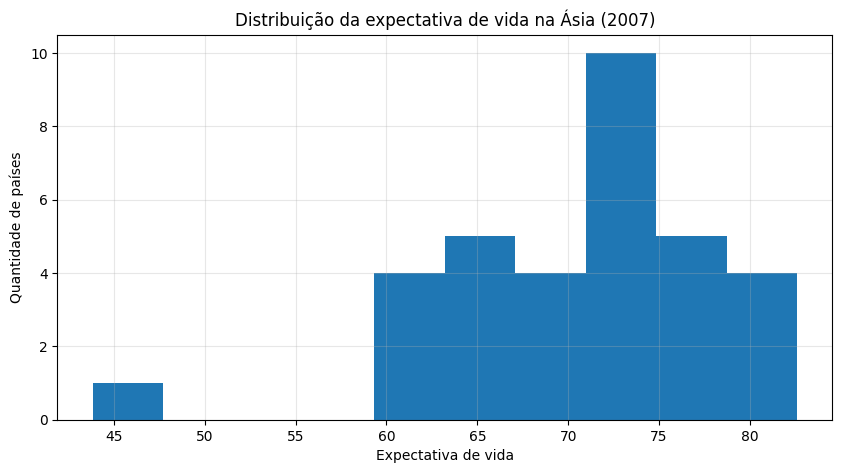

In [47]:
grafico_histograma(
    valores=df_asia_2007["lifeExp"],
    bins=10,
    titulo="Distribuição da expectativa de vida na Ásia (2007)",
    xlabel="Expectativa de vida",
    ylabel="Quantidade de países",
)

#### Trajetórias Asiáticas Selecionadas

In [48]:
df_asia = df[(df["continent"] == 'Asia')].sort_values("lifeExp", ascending=False)
df_asia

,country,year,pop,continent,lifeExp,gdpPercap
835,Japan,2007,127467972.0,Asia,82.603,31656.068060
703,Hong Kong China,2007,6980412.0,Asia,82.208,39724.978670
834,Japan,2002,127065841.0,Asia,82.000,28604.591900
702,Hong Kong China,2002,6762476.0,Asia,81.495,30209.015160
799,Israel,2007,6426679.0,Asia,80.745,25523.277100
...,...,...,...,...,...,...
1700,Yemen Rep.,1952,4963829.0,Asia,32.548,781.717576
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
229,Cambodia,1977,6978607.0,Asia,31.220,524.972183
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030


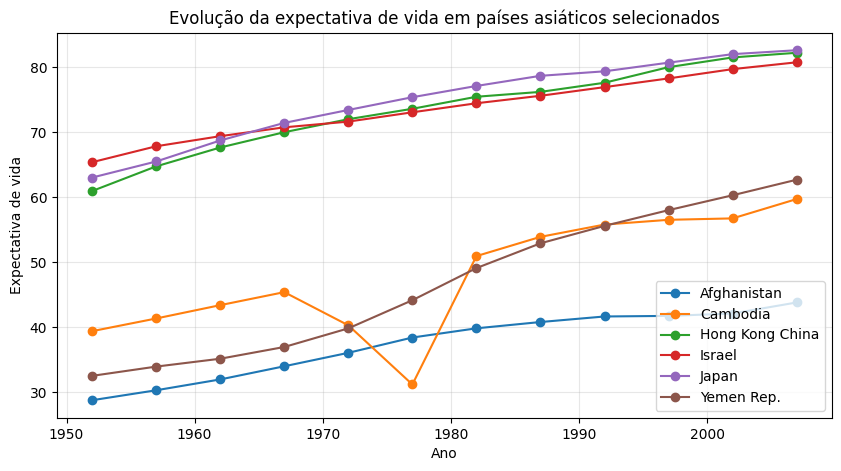

In [49]:
grafico_linhas_por_grupo(
    data_frame=df_asia,
    grupo="country",
    coluna_x="year",
    coluna_y="lifeExp",
    titulo="Evolução da expectativa de vida em países asiáticos selecionados",
    xlabel="Ano",
    ylabel="Expectativa de vida",
    grupos=["Japan", "Hong Kong China", "Israel", "Afghanistan", "Cambodia", "Yemen Rep."],
    figsize=(10, 5),
)

A análise da Ásia em 2007 foi priorizada por representar o ano mais recente do dataset e por evidenciar a heterogeneidade interna do continente. Embora a média continental asiática não esteja entre as mais altas, alguns países asiáticos aparecem entre os líderes globais em expectativa de vida.

### 10.2 Países Selecionados

Para complementar a análise por continentes, foram selecionados países de grande relevância demográfica, econômica e regional. O objetivo não é representar todos os países, mas observar trajetórias distintas de expectativa de vida ao longo do tempo.


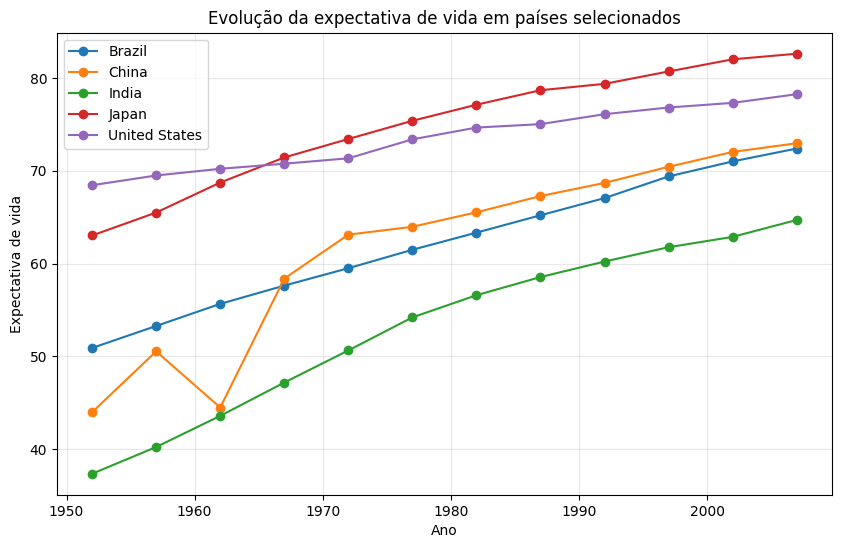

,country,year,continent,lifeExp,gdpPercap,pop
175,Brazil,1952,Americas,50.91700,2108.944355,5.660256e+07
176,Brazil,1957,Americas,53.28500,2487.365989,6.555117e+07
177,Brazil,1962,Americas,55.66500,3336.585802,7.603939e+07
178,Brazil,1967,Americas,57.63200,3429.864357,8.804982e+07
179,Brazil,1972,Americas,59.50400,4985.711467,1.008401e+08
180,Brazil,1977,Americas,61.48900,6660.118654,1.143140e+08
181,Brazil,1982,Americas,63.33600,7030.835878,1.289629e+08
182,Brazil,1987,Americas,65.20500,7807.095818,1.429381e+08
183,Brazil,1992,Americas,67.05700,6950.283021,1.559760e+08
184,Brazil,1997,Americas,69.38800,7957.980824,1.685467e+08


In [50]:
paises_foco = ["Brazil", "China", "India", "United States", "Japan"]

df_paises_foco = (
    df[df["country"].isin(paises_foco)]
    .sort_values(["country", "year"])
    .copy()
)

grafico_linhas_por_grupo(
    data_frame=df_paises_foco,
    grupo="country",
    coluna_x="year",
    coluna_y="lifeExp",
    titulo="Evolução da expectativa de vida em países selecionados",
    xlabel="Ano",
    ylabel="Expectativa de vida",
    figsize=(10, 6),
)

df_paises_foco[["country", "year", "continent", "lifeExp", "gdpPercap", "pop"]].head(15)

A comparação evidencia trajetórias distintas entre países populosos e economicamente relevantes. Japão e Estados Unidos já partem de patamares elevados de expectativa de vida, enquanto China, Índia e Brasil apresentam crescimento expressivo ao longo do período. Essa análise reforça que médias continentais podem esconder trajetórias nacionais muito diferentes.

## 11. PIB, População e Qualidade de Vida


### 11.1 Distribuição do PIB per capita

O histograma mostra que a maior parte das observações está concentrada em faixas baixas e intermediárias de PIB per capita, enquanto poucos países/anos aparecem com valores muito altos. Essa concentração cria uma cauda à direita e torna a escala linear pouco adequada para visualizar todos os grupos. Por isso, a escala logarítmica ajuda a comparar melhor países com níveis de renda muito diferentes.


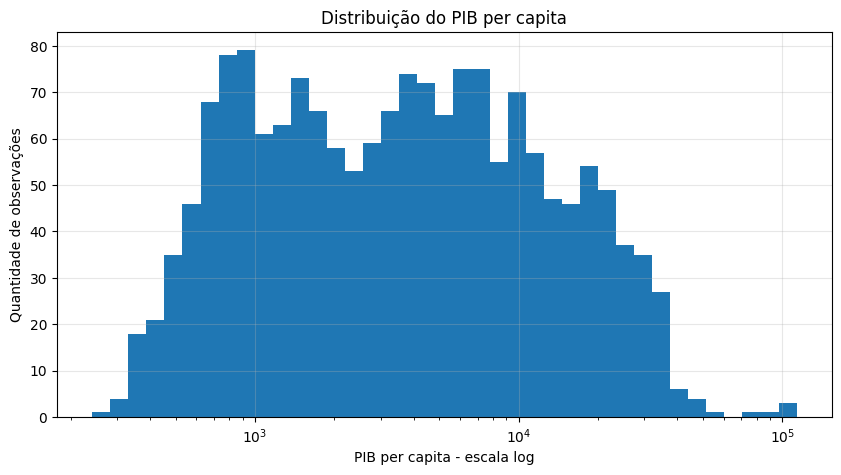

In [51]:
gdp_percap_valid = df_econ["gdpPercap"].dropna()
gdp_percap_valid = gdp_percap_valid[gdp_percap_valid > 0]

bins = np.logspace(
    np.log10(gdp_percap_valid.min()),
    np.log10(gdp_percap_valid.max()),
    40
)

grafico_histograma(
    valores=gdp_percap_valid,
    bins=bins,
    titulo="Distribuição do PIB per capita",
    xlabel="PIB per capita - escala log",
    ylabel="Quantidade de observações",
    scale_x=Scale.LOG.value,
)

A distribuição do PIB per capita mostra uma forte desigualdade econômica entre países e períodos históricos do dataset. Mesmo utilizando escala logarítmica no eixo X, observa-se que a maior parte das observações está concentrada em faixas mais baixas e intermediárias de PIB per capita, enquanto poucas observações aparecem nas faixas muito elevadas.

Esse padrão indica que o desenvolvimento econômico não está distribuído de forma homogênea. A presença de uma "cauda longa" à direita revela que existe um grupo menor de países/anos com níveis de renda per capita muito superiores à maioria das observações. Em outras palavras, poucos países em determinados períodos concentram valores muito altos de PIB per capita, enquanto grande parte da base permanece em níveis econômicos mais modestos.

A escala logarítmica é importante porque reduz a compressão visual causada por valores extremos. Sem essa transformação, países com PIB per capita muito elevado dominariam o eixo horizontal e dificultariam a visualização das diferenças entre países de baixa e média renda.

Essa distribuição também ajuda a interpretar os gráficos posteriores entre PIB per capita e expectativa de vida. Como a renda é muito assimétrica, a relação entre desenvolvimento econômico e qualidade de vida não deve ser analisada em escala linear simples. A escala logarítmica permite observar melhor como aumentos de renda em países mais pobres e intermediários parecem estar associados a mudanças mais expressivas nos indicadores de bem-estar, enquanto nos países mais ricos os ganhos adicionais tendem a ser menores.

### 11.2 PIB per capita vs Expectativa de Vida


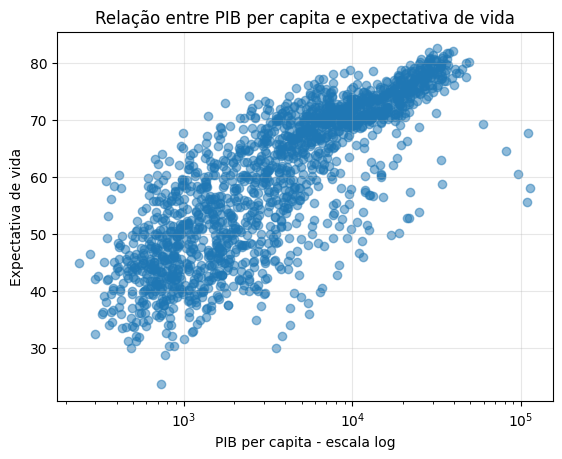

In [52]:
grafico_scatter(
    data_frame=df,
    coluna_x="gdpPercap",
    coluna_y="lifeExp",
    titulo="Relação entre PIB per capita e expectativa de vida",
    xlabel="PIB per capita - escala log",
    ylabel="Expectativa de vida",
    scale_x=Scale.LOG.value,
    alpha=0.5,
)


### 11.3 Correlação entre Variáveis Principais

<Axes: >

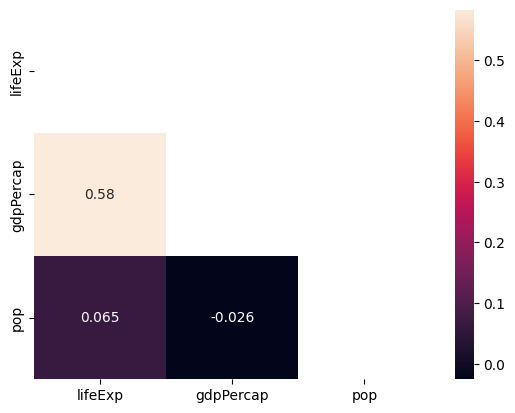

In [53]:


mask = np.triu(np.ones_like(df[["lifeExp", "gdpPercap", "pop"]].corr().round(2),dtype=bool))
sns.heatmap(data=df[["lifeExp", "gdpPercap", "pop"]].corr(), annot=True, mask=mask)

#### Reforço Estatístico: Pearson e Spearman

Além da matriz de correlação, foi realizada uma comparação entre Pearson e Spearman para avaliar a associação entre PIB per capita e expectativa de vida. Pearson mede associação linear, enquanto Spearman mede associação monotônica baseada no ranking das observações. A comparação entre as duas métricas ajuda a verificar se a relação observada depende apenas de uma tendência linear ou se também aparece quando olhamos a ordenação dos países por renda e expectativa de vida.


In [54]:
df_corr_pib = df[["lifeExp", "gdpPercap"]].dropna().copy()
df_corr_pib["log_gdpPercap"] = np.log10(df_corr_pib["gdpPercap"])

pearson_log = df_corr_pib[["log_gdpPercap", "lifeExp"]].corr(method="pearson").iloc[0, 1]
spearman = df_corr_pib[["gdpPercap", "lifeExp"]].corr(method="spearman").iloc[0, 1]
pearson_raw = df_corr_pib[["gdpPercap", "lifeExp"]].corr(method="pearson").iloc[0, 1]

pd.DataFrame({
    "metrica": [
        "Pearson — PIB per capita original vs lifeExp",
        "Pearson — log10(PIB per capita) vs lifeExp",
        "Spearman — PIB per capita vs lifeExp"
    ],
    "correlacao": [pearson_raw, pearson_log, spearman]
}).round(3)

,metrica,correlacao
0,Pearson — PIB per capita original vs lifeExp,0.584
1,Pearson — log10(PIB per capita) vs lifeExp,0.808
2,Spearman — PIB per capita vs lifeExp,0.826


Os resultados reforçam a associação positiva entre PIB per capita e expectativa de vida. A correlação com o PIB em escala logarítmica tende a representar melhor o padrão visual observado no gráfico de dispersão, pois a relação entre renda e longevidade apresenta ganhos mais fortes em faixas baixas e intermediárias de renda, com possível saturação nos níveis mais altos. Spearman complementa a análise ao verificar se países com maior PIB tendem a ocupar posições mais altas em expectativa de vida, mesmo sem assumir linearidade perfeita.

### 11.4 Países com PIB Alto e Expectativa Abaixo do Esperado


In [55]:
limiar_pib_alto = df_2007["gdpPercap"].quantile(0.75)
limiar_pib_alto


np.float64(18008.835639999998)

In [56]:
paises_ricos = df_2007[df_2007["gdpPercap"] >= limiar_pib_alto]
paises_ricos

,country,year,pop,continent,lifeExp,gdpPercap
71,Australia,2007,20434176.0,Oceania,81.235,34435.36744
84,Austria,2007,8199783.0,Europe,79.829,36126.49270
96,Bahrain,2007,708573.0,Asia,75.635,29796.04834
120,Belgium,2007,10392226.0,Europe,79.441,33692.60508
260,Canada,2007,33390141.0,Americas,80.653,36319.23501
419,Czech Republic,2007,10228744.0,Europe,76.486,22833.30851
431,Denmark,2007,5468120.0,Europe,78.332,35278.41874
547,Finland,2007,5238460.0,Europe,79.313,33207.08440
559,France,2007,61083916.0,Europe,80.657,30470.01670
602,Germany,2007,82400996.0,Europe,79.406,32170.37442


In [57]:
ricos_baixa_life = top_n(
    paises_ricos,
    coluna="lifeExp",
    n=10,
    ascending=True,
    colunas=["country", "continent", "lifeExp", "gdpPercap", "pop"],
)
ricos_baixa_life


,country,continent,lifeExp,gdpPercap,pop
1351,Saudi Arabia,Asia,72.777,21654.83194,27601038.0
715,Hungary,Europe,73.338,18008.94444,9956108.0
1411,Slovak Republic,Europe,74.663,18678.31435,5447502.0
96,Bahrain,Asia,75.635,29796.04834,708573.0
1195,Oman,Asia,75.640,22316.19287,3204897.0
419,Czech Republic,Europe,76.486,22833.30851,10228744.0
895,Kuwait,Asia,77.588,47306.98978,2505559.0
1423,Slovenia,Europe,77.926,25768.25759,2009245.0
1279,Portugal,Europe,78.098,20509.64777,10642836.0
1651,United States,Americas,78.242,42951.65309,301139947.0


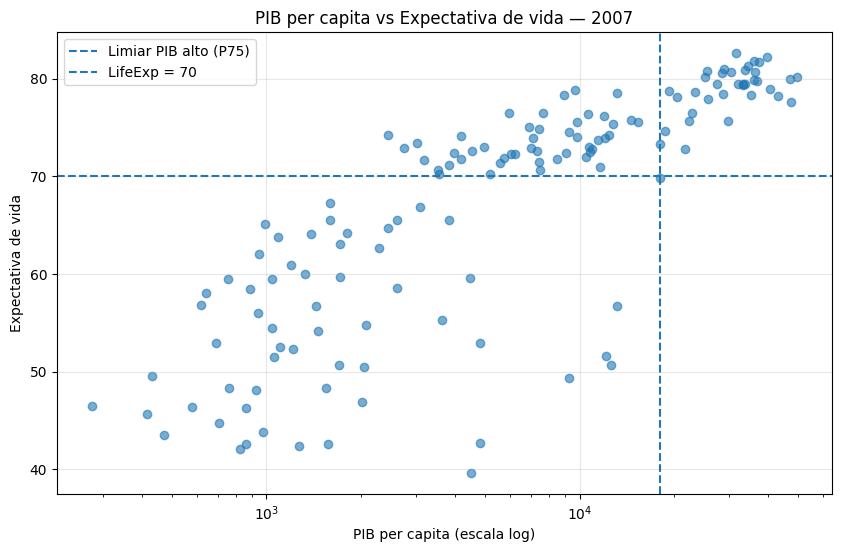

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_2007["gdpPercap"],
    df_2007["lifeExp"],
    alpha=0.6,
)

plt.axvline(
    limiar_pib_alto,
    linestyle="--",
    label="Limiar PIB alto (P75)",
)

plt.axhline(
    70,
    linestyle="--",
    label="LifeExp = 70",
)

plt.xscale(Scale.LOG.value)
aplicar_formatacao_grafico(
    titulo="PIB per capita vs Expectativa de vida — 2007",
    xlabel="PIB per capita (escala log)",
    ylabel="Expectativa de vida",
    legend=True,
)


#### PIB per capita e Expectativa de Vida em 2007

O gráfico mostra uma associação positiva entre PIB per capita e expectativa de vida em 2007. Países com menor PIB per capita concentram-se majoritariamente em faixas mais baixas de expectativa de vida, enquanto países com maior PIB per capita aparecem, em geral, acima de 70 anos.

A linha vertical representa o grupo de países com PIB per capita mais elevado, acima do percentil 75. Dentro do dataset analisado, países com maior renda per capita tendem a apresentar valores mais altos de longevidade; essa associação não determina causalidade.

Os casos com expectativa de vida relativamente baixa em faixas intermediárias de PIB sugerem perguntas adicionais, o que indica que a renda não explica tudo.

Para entender melhor por que alguns países ficam abaixo do esperado, seria necessário olhar outras informações, como mortalidade, acesso a serviços básicos, desigualdade interna ou contexto histórico. Essas dimensões aparecem aqui como caminhos para investigação futura, não como conclusões diretas deste notebook.


In [59]:
df_2007["log_gdpPercap"] = np.log10(df_2007["gdpPercap"])

coef = np.polyfit(
    df_2007["log_gdpPercap"],
    df_2007["lifeExp"],
    deg=1,
)

df_2007["lifeExp_esperada"] = (
    coef[0] * df_2007["log_gdpPercap"] + coef[1]
)

df_2007["residuo_lifeExp"] = (
    df_2007["lifeExp"] - df_2007["lifeExp_esperada"]
)

paises_abaixo_esperado = top_n(
    df_2007[df_2007["gdpPercap"] >= limiar_pib_alto],
    coluna="residuo_lifeExp",
    n=10,
    ascending=True,
)

paises_abaixo_esperado[
    ["country", "continent", "lifeExp", "gdpPercap", "lifeExp_esperada", "residuo_lifeExp"]
]


,country,continent,lifeExp,gdpPercap,lifeExp_esperada,residuo_lifeExp
895,Kuwait,Asia,77.588,47306.98978,82.483545,-4.895545
1351,Saudi Arabia,Asia,72.777,21654.83194,76.855064,-4.078064
1651,United States,Americas,78.242,42951.65309,81.787877,-3.545877
96,Bahrain,Asia,75.635,29796.04834,79.153817,-3.518817
1183,Norway,Europe,80.196,49357.19017,82.789127,-2.593127
787,Ireland,Europe,78.885,40675.99635,81.395779,-2.510779
1399,Singapore,Asia,79.972,47143.17964,82.458561,-2.486561
715,Hungary,Europe,73.338,18008.94444,75.527155,-2.189155
431,Denmark,Europe,78.332,35278.41874,80.370339,-2.038339
1195,Oman,Asia,75.640,22316.19287,77.071752,-1.431752


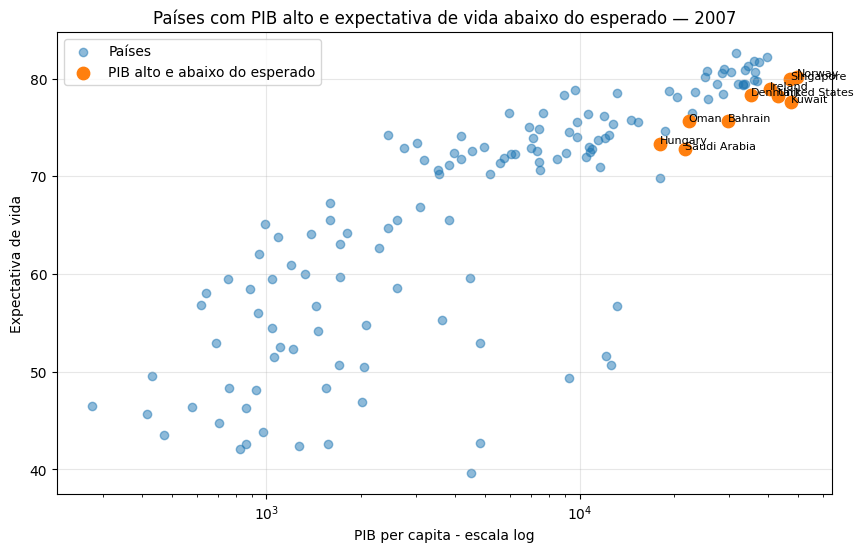

In [60]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_2007["gdpPercap"],
    df_2007["lifeExp"],
    alpha=0.5,
    label="Países",
)

plt.scatter(
    paises_abaixo_esperado["gdpPercap"],
    paises_abaixo_esperado["lifeExp"],
    s=80,
    label="PIB alto e abaixo do esperado",
)

anotar_paises(
    data_frame=paises_abaixo_esperado,
    coluna_x="gdpPercap",
    coluna_y="lifeExp",
)

plt.xscale(Scale.LOG.value)
aplicar_formatacao_grafico(
    titulo="Países com PIB alto e expectativa de vida abaixo do esperado — 2007",
    xlabel="PIB per capita - escala log",
    ylabel="Expectativa de vida",
    legend=True,
)


A análise de países com PIB per capita elevado e expectativa de vida abaixo do esperado mostra que renda, embora relevante, não explica sozinha a variação observada na longevidade. Alguns países apresentam desempenho inferior ao esperado considerando a sua posição econômica relativa.

Fatores como distribuição de renda, acesso efetivo a serviços de saúde, saneamento, educação, segurança alimentar, estabilidade política e mortalidade infantil podem ser investigados em estudos complementares; esta análise não conclui que causaram os resíduos observados.

A análise também mostra a importância de observar exceções à tendência geral: o gráfico registra associação entre PIB per capita e expectativa de vida, sem implicar que crescimento econômico produza automaticamente melhores condições de vida.


### 11.5 População vs Expectativa de Vida


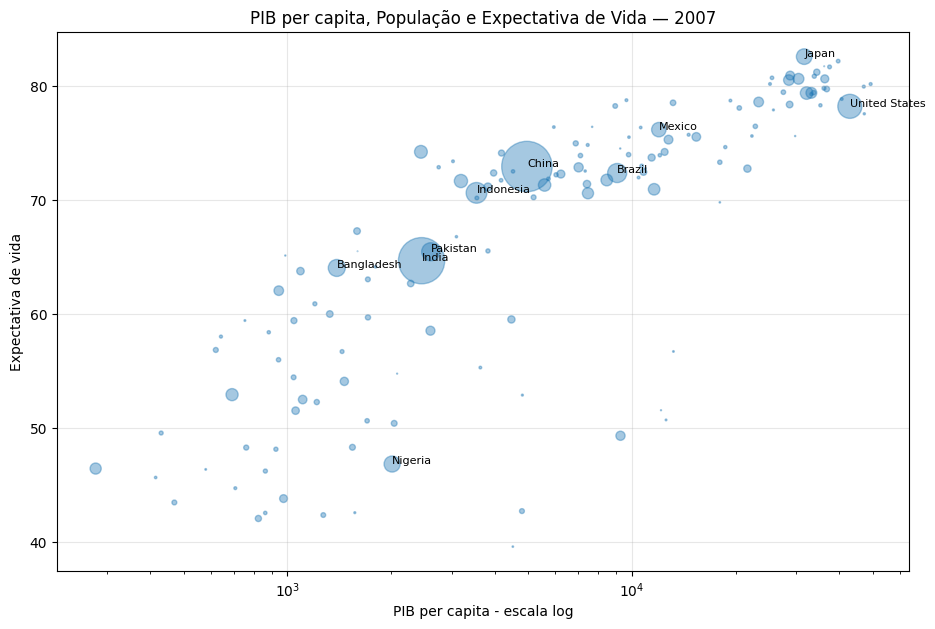

In [61]:
top_pop = top_n(df_2007, coluna="pop", n=10)

plt.figure(figsize=(11, 7))

plt.scatter(
    df_2007["gdpPercap"],
    df_2007["lifeExp"],
    s=df_2007["pop"] / 1_000_000,
    alpha=0.4,
)

anotar_paises(
    data_frame=top_pop,
    coluna_x="gdpPercap",
    coluna_y="lifeExp",
)

plt.xscale(Scale.LOG.value)
aplicar_formatacao_grafico(
    titulo="PIB per capita, População e Expectativa de Vida — 2007",
    xlabel="PIB per capita - escala log",
    ylabel="Expectativa de vida",
)


In [62]:
top_pop[
    ["country", "continent", "pop", "lifeExp", "gdpPercap"]
]

,country,continent,pop,lifeExp,gdpPercap
308,China,Asia,1.318683e+09,72.961,4959.114854
739,India,Asia,1.110396e+09,64.698,2452.210407
1651,United States,Americas,3.011399e+08,78.242,42951.653090
751,Indonesia,Asia,2.235470e+08,70.650,3540.651564
186,Brazil,Americas,1.900106e+08,72.390,9065.800825
1207,Pakistan,Asia,1.692706e+08,65.483,2605.947580
108,Bangladesh,Asia,1.504483e+08,64.062,1391.253792
1171,Nigeria,Africa,1.350312e+08,46.859,2013.977305
835,Japan,Asia,1.274680e+08,82.603,31656.068060
1027,Mexico,Americas,1.087009e+08,76.195,11977.574960


##### População vs Qualidade de Vida

Aqui a pergunta foi simples: países mais populosos parecem ter expectativa de vida maior, menor ou não há um padrão claro?. Para isso, foi utilizado o ano de 2007, por ser o período mais recente disponível no dataset.

A população foi representada em escala logarítmica, pois há grande diferença entre países pouco populosos e países extremamente populosos, como China e Índia. Essa transformação melhora a visualização e evita que países com populações muito grandes comprimam os demais pontos no gráfico.

O gráfico não mostra um padrão simples entre tamanho da população e expectativa de vida. Países muito populosos aparecem em faixas diferentes de longevidade, o que sugere que população, sozinha, não explica o indicador. Desta forma sugere-se que o tamanho populacional não é suficiente para explicar a qualidade de vida.

## 12. Análises Econômicas Complementares com Dados Enriquecidos

### 12.1 PIB Total em USD Correntes

Na preparação do dataset enriquecido, `gdp_usd_correntes` foi identificado como PIB total em USD correntes e convertido apenas para unidades de apresentação (bilhões e trilhões). Seus valores não devem ser interpretados como crescimento real ajustado por inflação.

#### Evolução Existente do PIB per capita por Continente

O gráfico preservado abaixo utiliza `gdpPercap`, e não `gdp_usd_correntes`. Ele complementa a evolução da expectativa de vida comparando o PIB médio por continente.


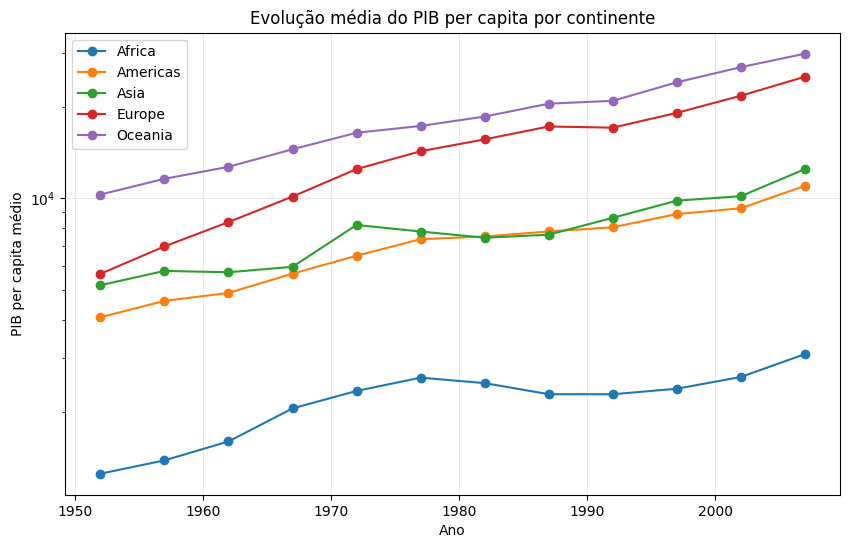

In [63]:
gdp_continent = (
    df_econ
    .dropna(subset=["gdpPercap"])
    .groupby(["continent", "year"])["gdpPercap"]
    .mean()
    .reset_index()
)

grafico_linhas_por_grupo(
    data_frame=gdp_continent,
    grupo="continent",
    coluna_x="year",
    coluna_y="gdpPercap",
    titulo="Evolução média do PIB per capita por continente",
    xlabel="Ano",
    ylabel="PIB per capita médio",
    scale_y=Scale.LOG.value,
    figsize=(10, 6),
)

O gráfico mostra diferenças expressivas no PIB médio entre continentes. A escala logarítmica é utilizada porque a distribuição de renda é muito assimétrica, com grande distância entre continentes e países de renda baixa, média e alta.

Essa visualização aponta uma associação entre dimensão econômica e parte das desigualdades observadas na expectativa de vida; ela não oferece explicação causal e não representa evolução do PIB real.


### 12.2 Mortalidade e Expectativa de Vida

Entre os indicadores enriquecidos, `infant_mortality_rate` possui maior cobertura relativa e é usado apenas para complementar a análise de expectativa de vida.


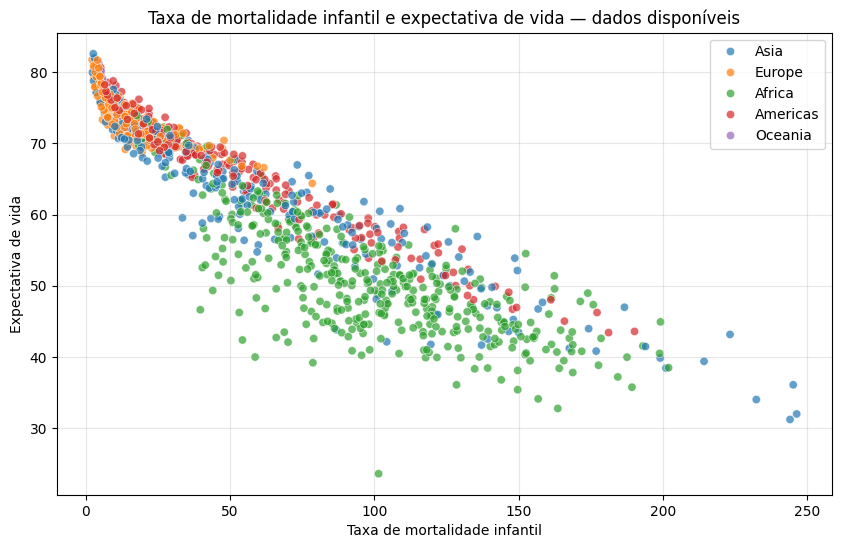

In [64]:
mortality_data = df_econ.dropna(subset=["infant_mortality_rate", "lifeExp"]).copy()

grafico_scatter_categorico(
    data_frame=mortality_data,
    coluna_x="infant_mortality_rate",
    coluna_y="lifeExp",
    titulo="Taxa de mortalidade infantil e expectativa de vida — dados disponíveis",
    xlabel="Taxa de mortalidade infantil",
    ylabel="Expectativa de vida",
)

O gráfico indica uma associação negativa entre mortalidade e expectativa de vida: observações com maiores taxas de mortalidade tendem a apresentar menor expectativa de vida. Esse padrão é coerente com a interpretação demográfica esperada e reforça a utilidade da variável como complemento à análise principal.

Ainda assim, por se tratar de correlação observacional, o resultado não deve ser interpretado como prova causal isolada.

### 12.3 Água Potável - Análise Limitada a Anos Recentes

A variável `drinking_water` é um indicador complementar e sua cobertura está concentrada em 2002 e 2007. Por isso, esta análise é limitada aos anos com maior disponibilidade de dados e não sustenta conclusões causais ou históricas completas.


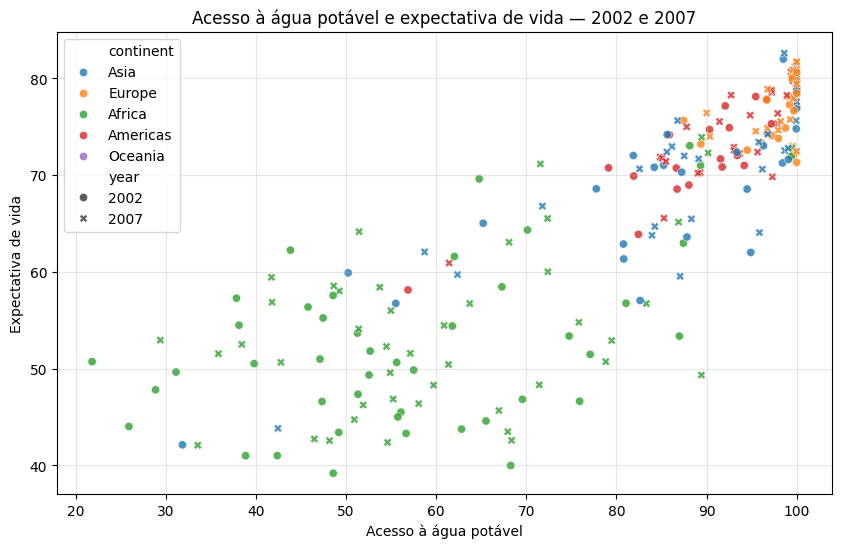

In [65]:
if "drinking_water" in df_econ.columns:
    water_recent = df_econ[
        df_econ["year"].isin([2002, 2007])
    ].dropna(subset=["drinking_water", "lifeExp"]).copy()

    grafico_scatter_categorico(
        data_frame=water_recent,
        coluna_x="drinking_water",
        coluna_y="lifeExp",
        titulo="Acesso à água potável e expectativa de vida — 2002 e 2007",
        xlabel="Acesso à água potável",
        ylabel="Expectativa de vida",
        style="year",
        alpha=0.8,
    )
else:
    print("Coluna drinking_water não disponível no dataset enriquecido.")

A associação visual entre acesso à água potável e expectativa de vida aparece no subconjunto disponível. Como os dados estão concentrados em 2002 e 2007, a visualização funciona apenas como análise complementar para anos recentes e não permite atribuir causa à evolução histórica desde 1952.


### 12.4 Gasto em Saúde - Análise Limitada a Anos Recentes

Assim como `drinking_water`, `health_expenditure` é um indicador complementar de cobertura limitada. A análise abaixo considera apenas os registros disponíveis em 2002 e 2007, com interpretação exploratória.


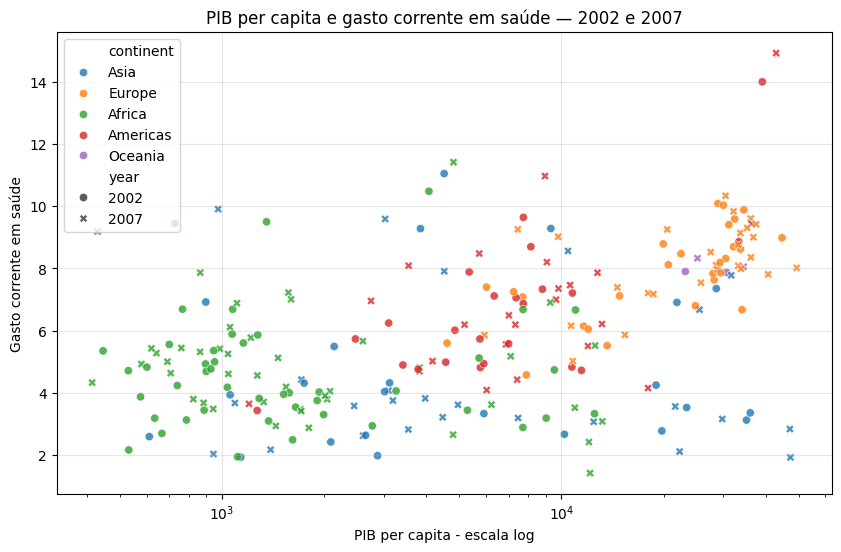

In [66]:
if "health_expenditure" in df_econ.columns:
    health_recent = df_econ[
        df_econ["year"].isin([2002, 2007])
    ].dropna(subset=["health_expenditure", "lifeExp", "gdpPercap"]).copy()

    grafico_scatter_categorico(
        data_frame=health_recent,
        coluna_x="gdpPercap",
        coluna_y="health_expenditure",
        titulo="PIB per capita e gasto corrente em saúde — 2002 e 2007",
        xlabel="PIB per capita - escala log",
        ylabel="Gasto corrente em saúde",
        style="year",
        scale_x=Scale.LOG.value,
        alpha=0.8,
    )
else:
    print("Coluna health_expenditure não disponível no dataset enriquecido.")

A visualização sugere diferenças entre países e continentes no percentual de gasto em saúde, mas a cobertura restrita impede conclusões históricas fortes. Esse indicador deve ser interpretado como recorte exploratório de anos recentes, não como evidência central da evolução econômica ao longo de todo o período analisado.

### 12.5 Matriz de Correlação com Indicadores Enriquecidos

A matriz de correlação abaixo deve ser interpretada com cautela, pois cada par de variáveis pode ter quantidades diferentes de observações disponíveis. `health_expenditure`, `drinking_water` e `literacy_rate` são complementares e limitados por cobertura; as associações não indicam causalidade.


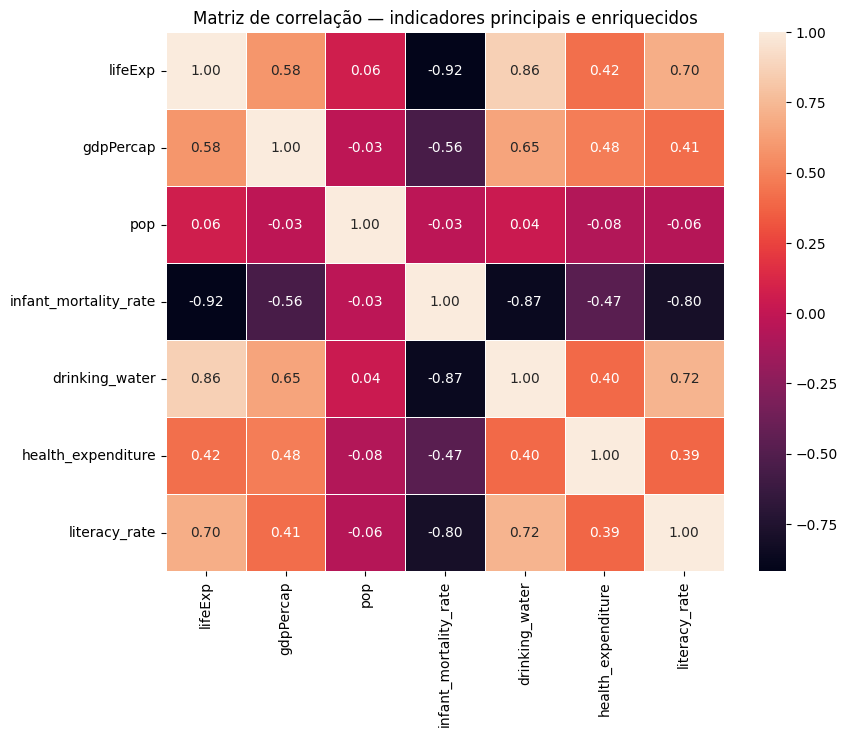

lifeExp                  1704
gdpPercap                1704
pop                      1704
infant_mortality_rate    1146
health_expenditure        241
drinking_water            238
literacy_rate              54
dtype: int64

In [67]:
corr_cols = [
    col for col in [
        "lifeExp",
        "gdpPercap",
        "pop",
        "infant_mortality_rate",
        "drinking_water",
        "health_expenditure",
        "literacy_rate"
    ] if col in df_econ.columns
]

corr_matrix = df_econ[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de correlação — indicadores principais e enriquecidos")
plt.show()

# Quantidade de pares válidos por variável para apoiar a interpretação
n_validos = df_econ[corr_cols].notna().sum().sort_values(ascending=False)
n_validos

A matriz reforça padrões esperados, como a associação positiva entre PIB e expectativa de vida e a associação negativa entre mortalidade e expectativa de vida. No entanto, variáveis com baixa cobertura, como `literacy_rate`, `drinking_water` e `health_expenditure`, não devem sustentar conclusões centrais do trabalho sem ressalvas.

## 13. Síntese dos Principais Insights

As análises mostram que a expectativa de vida aumentou de forma consistente entre 1952 e 2007. Porém, esse avanço não aconteceu do mesmo modo em todos os países e continentes.

Os principais achados foram:

- houve crescimento global da expectativa de vida ao longo do período;
- a média ponderada pela população revelou que países muito populosos influenciaram fortemente a leitura global, especialmente nos primeiros anos da série;
- Europa e Oceania apresentaram os maiores níveis médios de expectativa de vida;
- a África melhorou ao longo do tempo, mas permaneceu abaixo dos demais continentes;
- a Ásia apresentou forte heterogeneidade interna, com países entre os líderes globais e outros ainda em patamares inferiores;
- a comparação de países selecionados mostrou trajetórias nacionais distintas, reforçando que médias continentais podem esconder diferenças internas relevantes;
- o mapa mundial de 2007 ajuda a visualizar a distribuição espacial da expectativa de vida, reforçando padrões regionais já observados nas análises quantitativas;
- o PIB apresentou relação positiva com expectativa de vida, especialmente quando analisado em escala logarítmica;
- Pearson e Spearman reforçaram estatisticamente a associação entre PIB e expectativa de vida, com ressalva de que correlação não implica causalidade;
- a população total, isoladamente, não demonstra relação direta forte com expectativa de vida;
- alguns países apresentam expectativa de vida abaixo do esperado para seu nível de PIB, indicando que renda não explica sozinha a qualidade de vida;
- indicadores enriquecidos, como mortalidade, água potável e gasto em saúde, ajudam a complementar a análise, mas sua cobertura limitada exige cautela metodológica.

## 14. Aplicações Práticas e Implicações

Os resultados mostram que a expectativa de vida está relacionada ao nível de renda, à mortalidade e às diferenças regionais. Mesmo assim, o PIB sozinho não explica tudo: alguns países aparecem abaixo do esperado para seu nível de renda.

Do ponto de vista de políticas públicas, os resultados podem orientar investigações mais específicas sobre fatores associados à longevidade. Saúde pública, acesso a serviços essenciais, saneamento, educação e desigualdades sociais são hipóteses para investigação complementar, não conclusões diretas do notebook.

Uma aplicação prática seria identificar países ou regiões com expectativa de vida abaixo do esperado para seu nível de renda e direcionar estudos posteriores, com dados apropriados, sobre mortalidade, acesso à saúde, saneamento, educação e desigualdade interna.


## 15. Limitações da Análise

Apesar dos padrões identificados, algumas limitações precisam ser consideradas:

- o dataset Gapminder possui observações em intervalos de 5 anos, não permitindo análise anual detalhada;
- a média global simples dá o mesmo peso a países com populações muito diferentes;
- a média ponderada pela população muda a unidade de análise, dando maior influência a países populosos;
- algumas análises por continente podem esconder grande heterogeneidade interna;
- a Oceania possui poucos países no dataset, o que torna sua média menos comparável à de continentes mais numerosos;
- correlações, incluindo Pearson e Spearman, não indicam causalidade;
- o mapa mundial é uma visualização complementar;
- o PIB total em USD correntes não deve ser interpretado como crescimento econômico real, pois não está ajustado por inflação;
- variáveis externas enriquecidas apresentaram baixa cobertura temporal e geográfica, especialmente `health_expenditure`, `drinking_water` e `literacy_rate`, limitando sua utilização como evidência central;
- as análises com dados enriquecidos devem ser interpretadas como complementares e, em alguns casos, restritas aos anos de 2002 e 2007.

## 16. Conclusão e Reflexão Final

### Conclusão

O principal resultado do trabalho é que a expectativa de vida melhorou bastante entre 1952 e 2007, mas essa melhora foi desigual. Alguns países e continentes permaneceram em posições mais favoráveis durante quase toda a série, enquanto outros avançaram muito sem alcançar os mesmos patamares.

Também foi observada uma relação entre renda e expectativa de vida, mas ela não deve ser lida como causalidade direta. O PIB ajuda a entender parte do padrão, mas não explica sozinho as diferenças entre países.

Variáveis complementares, como mortalidade, acesso à água potável, gasto em saúde e alfabetização, enriquecem a discussão apenas dentro dos limites de sua cobertura.


### Reflexão Final


O maior desafio foi organizar a análise sem depender apenas de médias gerais. A comparação entre média simples e média ponderada pela população mostrou que a forma de agregar os dados muda a interpretação. Comparar países, regiões e níveis de renda também ajudou a mostrar que o desenvolvimento humano não pode ser explicado por uma única métrica.

O principal aprendizado foi que uma boa análise exploratória exige mais do que gerar gráficos. É preciso validar os dados, escolher métricas adequadas, interpretar padrões com cuidado e reconhecer os limites da análise. As associações encontradas servem como ponto de partida para novas perguntas, mas não como prova direta das causas das diferenças de expectativa de vida.